# Importacion de librerias

In [114]:
from wget import download
from os import path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Descarga de datos

In [115]:

if (not path.exists('../data/arbolado-publico-lineal-2017-2018.csv')):
    download('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/atencion-ciudadana/arbolado-publico-lineal/arbolado-publico-lineal-2017-2018.csv', out='../data')

datos_arbolado= pd.read_csv("../data/arbolado-publico-lineal-2017-2018.csv")

/tmp/ipykernel_110254/1406665058.py:4: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  datos_arbolado= pd.read_csv("../data/arbolado-publico-lineal-2017-2018.csv")


# Exploracion inicial

In [116]:
datos_arbolado

,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370175,NaN,NaN,546140,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD3,Ceiba speciosa,3.3,Ocupada,Regular,A nivel,34.0,7.0
370176,NaN,NaN,546141,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD4,Melia azedarach,3.3,Ocupada,Regular,A nivel,45.0,8.0
370177,NaN,NaN,546142,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD5,Ceiba speciosa,3.3,Ocupada,Regular,A nivel,60.0,8.0
370178,NaN,NaN,546143,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD6,Ceiba speciosa,3.3,Ocupada,Regular,A nivel,64.0,8.0


In [117]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

Ya se detecta que hay ciertas columans que tienen bastantes nulos.

In [118]:
datos_arbolado.head()

,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0


In [119]:
datos_arbolado.describe()

,long,lat,comuna,diametro_altura_pecho,altura_arbol
count,354838.000000,354838.000000,370180.000000,369894.000000,365858.000000
mean,-58.458791,-34.612473,9.143735,31.986864,9.036132
std,0.041514,0.033695,3.876242,21.267623,4.894625
min,-58.530458,-34.697333,1.000000,0.000000,1.000000
25%,-58.491269,-34.637834,6.000000,17.000000,6.000000
50%,-58.465865,-34.615023,10.000000,29.000000,8.000000
75%,-58.428583,-34.586580,12.000000,43.000000,12.000000
max,-58.354003,-34.535972,15.000000,199.000000,40.000000


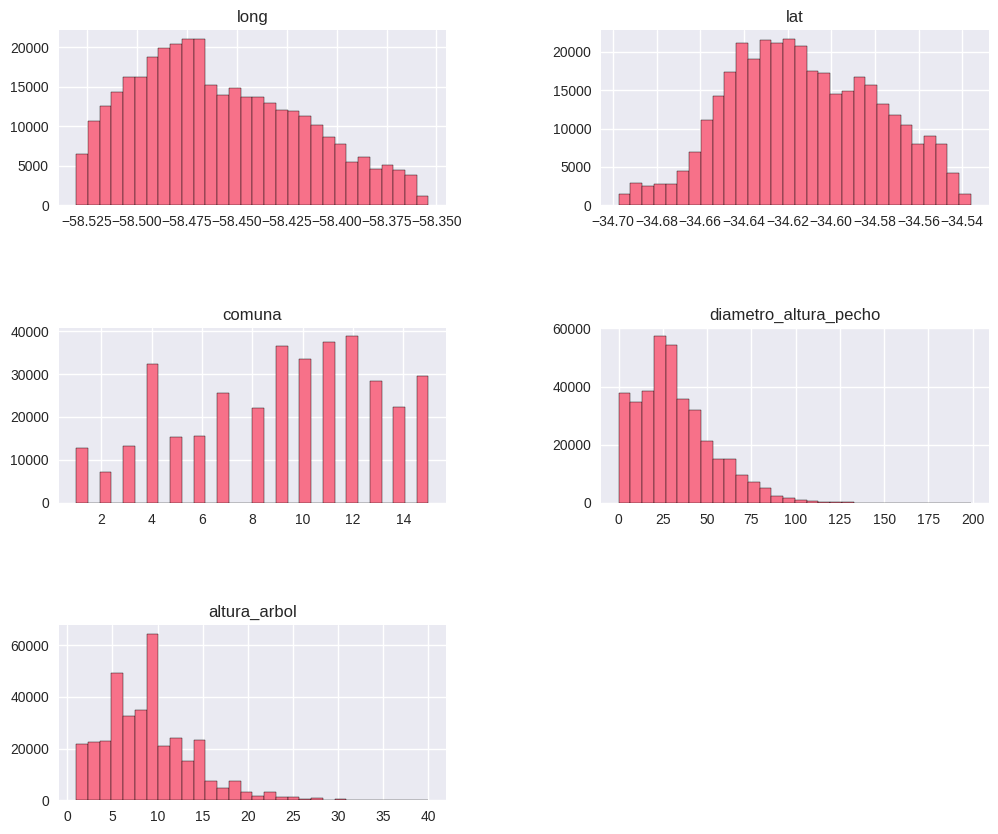

In [120]:
datos_arbolado.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

### Scatter arboles por latitud y longitud

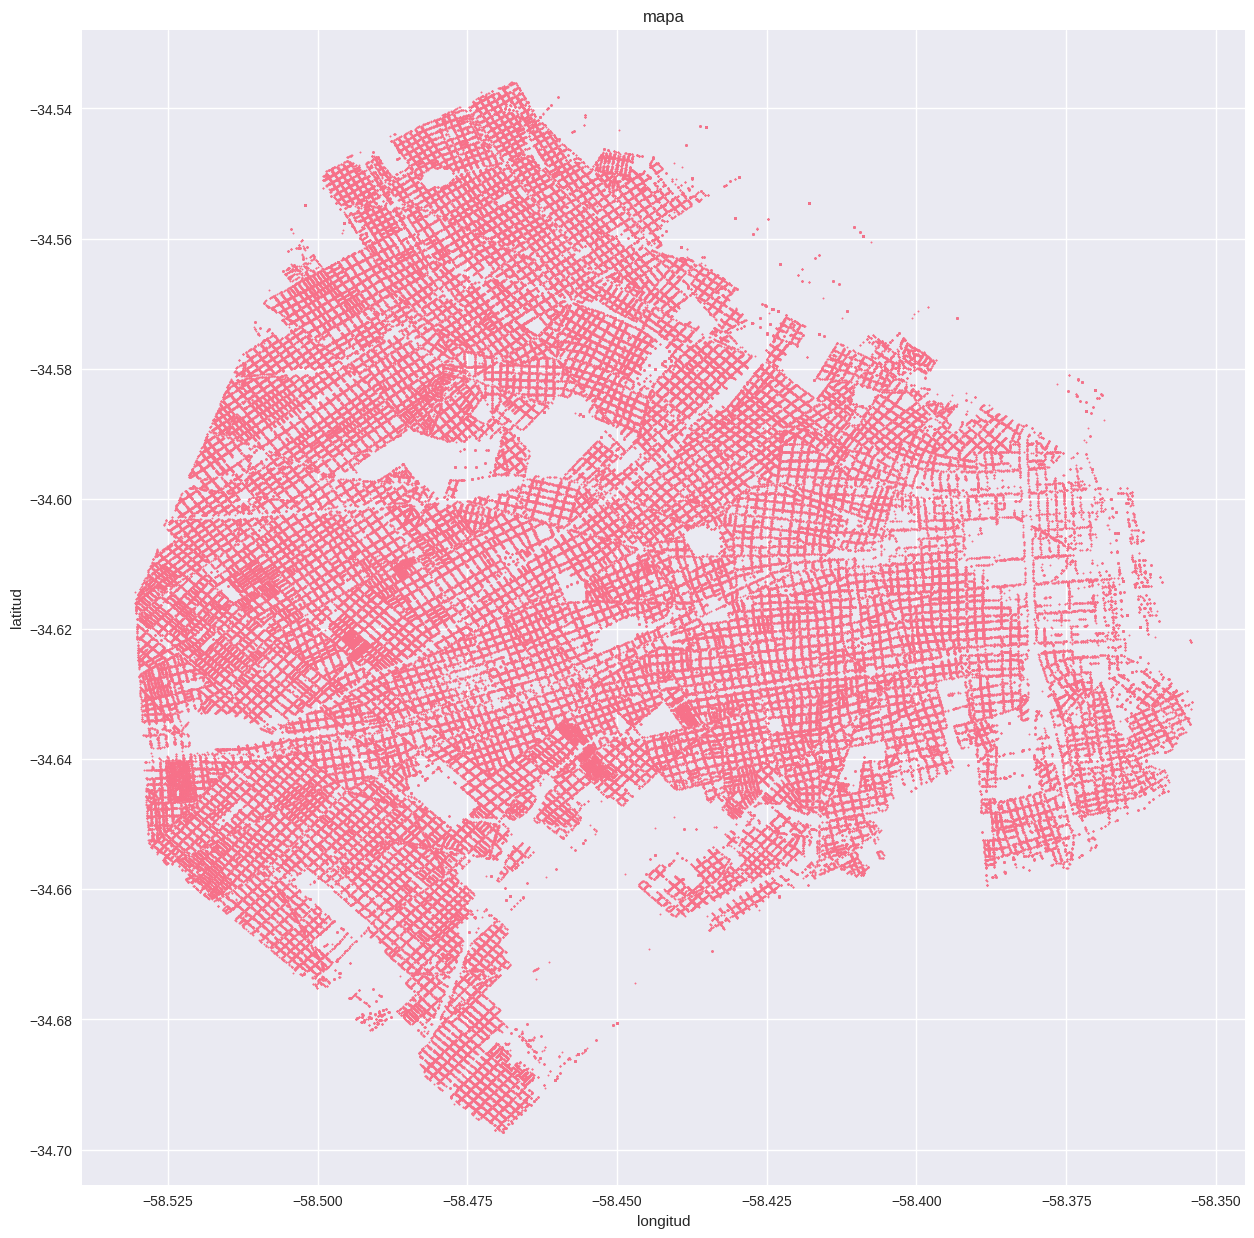

In [121]:
plt.figure(figsize=(15,15))
plt.scatter(datos_arbolado['long'], datos_arbolado['lat'], s=1)
plt.xlabel("longitud")
plt.ylabel("latitud")
plt.title("mapa")

plt.show()

# Analisis de cada columna individualmente

## Latitud y Longitud

**Se opto por eliminiar los arboles que no tienen especificado una latitud y longitud, dado que mas adelante se van a usar para limpiar otros atributos de mayor importancia**

In [122]:
datos_arbolado= datos_arbolado.dropna(subset=['lat','long'])
datos_arbolado

,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370125,-58.477279,-34.582165,545682,Lineal,15,244,Marsella,2500.0,NaN,MARSELLA,LD 13,Enterolobium contortisiliquum,NaN,Ocupada,Regular,A Nivel,9.0,4.0
370169,-58.470559,-34.595531,545935,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA1,Tipuana tipu,NaN,Ocupada,NaN,NaN,62.0,16.0
370170,-58.470559,-34.595531,545936,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA2,Tipuana tipu,NaN,Ocupada,NaN,NaN,76.0,16.0
370171,-58.470559,-34.595531,545937,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA3,Tipuana tipu,NaN,Ocupada,NaN,NaN,57.0,16.0


## nro_registro


In [123]:
datos_arbolado['nro_registro']

0          26779
1          30887
2          30904
3          31336
4          31337
           ...  
370125    545682
370169    545935
370170    545936
370171    545937
370172    545938
Name: nro_registro, Length: 354838, dtype: object

**Representa un identificador unico para cada arbol, no tiene sentido manteneral dado que no agrega informacion relevate, el dataframe incorpora el identificador**

In [124]:
datos_arbolado=datos_arbolado.drop('nro_registro',axis=1)

In [125]:
datos_arbolado

,long,lat,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370125,-58.477279,-34.582165,Lineal,15,244,Marsella,2500.0,NaN,MARSELLA,LD 13,Enterolobium contortisiliquum,NaN,Ocupada,Regular,A Nivel,9.0,4.0
370169,-58.470559,-34.595531,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA1,Tipuana tipu,NaN,Ocupada,NaN,NaN,62.0,16.0
370170,-58.470559,-34.595531,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA2,Tipuana tipu,NaN,Ocupada,NaN,NaN,76.0,16.0
370171,-58.470559,-34.595531,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA3,Tipuana tipu,NaN,Ocupada,NaN,NaN,57.0,16.0


## tipo_actividad

In [126]:
datos_arbolado['tipo_activ'].value_counts()



tipo_activ
Lineal      350511
Lineal        4092
lineal         157
Lineal          35
calle           33
LINEAL          10
Name: count, dtype: int64

Los tipos de actividad representan el tipo de relevamiento o censo que el arbol forma parte del arbolado publico lineal.
Los tipos son lineal y de calle. que representan lo mismo. por lo tanto el conjunto de datos representa arboles de alumbrado publico, es decir de la vereda.
**No tiene sentido matener esa columna, porque el mismo data set determina que es lineal y todos los ejemplares pertenecen a esa categoria; es reduntante**


In [127]:
datos_arbolado= datos_arbolado.drop('tipo_activ',axis=1)

## Comunas


### Las Comunas son diferentes secciones de buenos aires, donde en cada una hay diferentes barios. Tienen diferencias tanto en historia, cultura y infraestructura

In [128]:
datos_arbolado['comuna'].value_counts()

comuna
12    37111
9     35796
11    35478
10    32445
4     30066
15    28214
13    27267
7     25382
14    21162
8     19898
5     15112
6     15083
3     13267
1     11647
2      6910
Name: count, dtype: int64

/tmp/ipykernel_110254/204778770.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


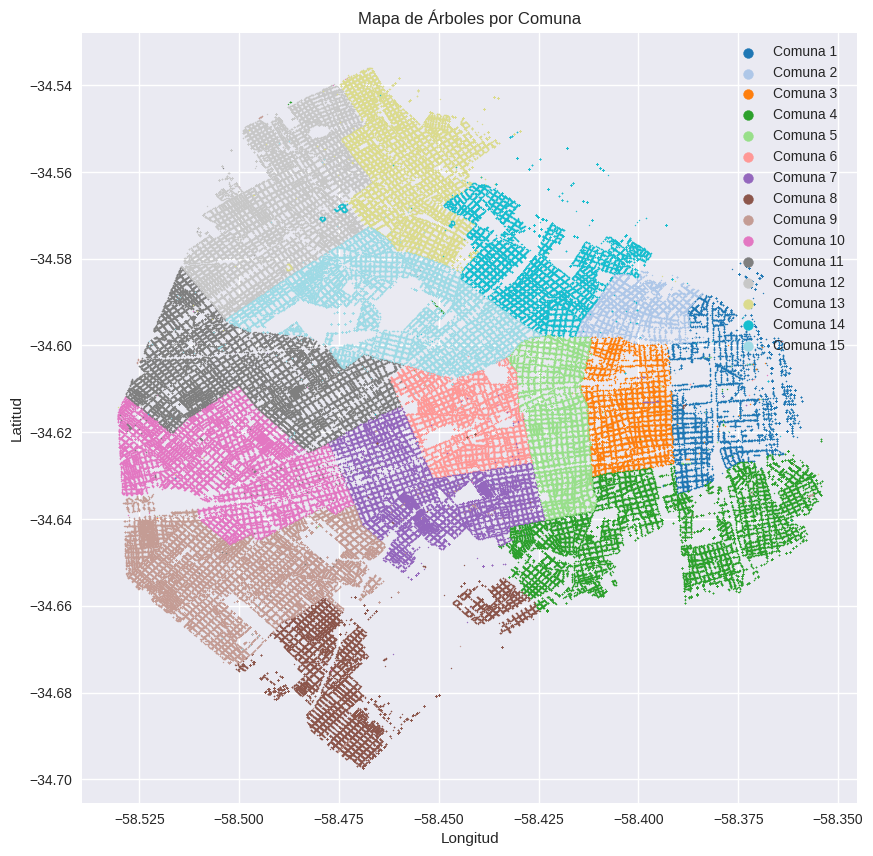

In [129]:
plt.figure(figsize=(10, 10))
categorias = sorted(datos_arbolado['comuna'].unique())
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, comuna in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['comuna'] == comuna]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=0.5,
        color=colores(i),
        label=f'Comuna {int(comuna)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por Comuna")
plt.legend(markerscale=10)
plt.show()

Vemos que hay arboles que tiene asosiadas comunas que no le corresponden. por lo tanto se decide limpiarlo con metodo de imputacion.
Se toma de un data set de buenos aires, los poligonos de las comunas de buenos aires y con geo pandas se le asigna a cada arbol su comuna real.

In [130]:
import pandas as pd
import geopandas as gpd


# 1. Cargar el mapa de Polígonos
gdf_comunas = gpd.read_file('../data/caba_comunas.geojson')

#
print("Columnas del mapa de comunas:")
print(gdf_comunas.head())

# 2. Convertir el DataFrame de árboles a un GeoDataFrame (Puntos)
# Usamos lat/lon para crear una geometría de tipo 'Point'
gdf_arboles = gpd.GeoDataFrame(
    datos_arbolado, 
    geometry=gpd.points_from_xy(datos_arbolado.long, datos_arbolado.lat)
)

# --- 3. LLevar a un sistema de referencia en comun
gdf_arboles.set_crs(epsg=4326, inplace=True)

# Verificamos el CRS de las comunas y lo convertimos si es necesario
print(f"\nCRS Árboles: {gdf_arboles.crs}")
print(f"CRS Comunas: {gdf_comunas.crs}")

if gdf_arboles.crs != gdf_comunas.crs:
    print("Convirtiendo CRS de comunas para que coincida...")
    gdf_comunas = gdf_comunas.to_crs(gdf_arboles.crs)

Columnas del mapa de comunas:
   ID          OBJETO  COMUNAS  \
0   1  LIMITE COMUNAL      2.0   
1   3  LIMITE COMUNAL      6.0   
2   6  LIMITE COMUNAL     10.0   
3   7  LIMITE COMUNAL     11.0   
4   8  LIMITE COMUNAL     12.0   

                                             BARRIOS     PERIMETRO  \
0                                           RECOLETA  21452.838648   
1                                          CABALLITO  10990.964471   
2  FLORESTA - MONTE CASTRO - VELEZ SARSFIELD - VE...  18332.037457   
3  VILLA DEL PARQUE - VILLA  DEVOTO - VILLA GRAL....  19987.696155   
4  COGHLAN - SAAVEDRA - VILLA PUEYRREDON - VILLA ...  17232.189372   

           AREA                                           geometry  
0  6.317265e+06  MULTIPOLYGON (((-58.38 -34.57002, -58.38002 -3...  
1  6.851029e+06  MULTIPOLYGON (((-58.43061 -34.60705, -58.43056...  
2  1.265656e+07  MULTIPOLYGON (((-58.48834 -34.62016, -58.4882 ...  
3  1.412004e+07  MULTIPOLYGON (((-58.49838 -34.59637, -58.49718...  

In [131]:

gdf_comunas_limpio = gdf_comunas.rename(columns={'COMUNAS': 'comuna_correcta'})


gdf_arboles_corregido = gpd.sjoin(
    gdf_arboles, 
    gdf_comunas_limpio[['comuna_correcta', 'geometry']], # Solo queremos esta columna
    how='left', 
    predicate='within'
)


In [132]:
# --- 1. Comparar la comuna original con la correcta ---

original_col = 'comuna'
correcta_col = 'comuna_correcta'

diferencias = gdf_arboles_corregido[
    gdf_arboles_corregido[original_col] != gdf_arboles_corregido[correcta_col]
].shape[0]

print(f"\nSe encontraron {diferencias} árboles con la comuna incorrecta.")

# --- 2. Reemplazar la columna original ---
# Creamos la columna final de 'comuna' con los valores corregidos
# (Usamos la corregida, y si falló el join, dejamos la original)
datos_arbolado['comuna'] = gdf_arboles_corregido[correcta_col].fillna(datos_arbolado[original_col])

print("\nLimpieza completada. La columna 'comuna_final' tiene los datos corregidos.")


Se encontraron 2317 árboles con la comuna incorrecta.

Limpieza completada. La columna 'comuna_final' tiene los datos corregidos.


In [ ]:
plt.figure(figsize=(10, 10))
categorias = sorted(datos_arbolado['comuna'].unique())
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, comuna in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['comuna'] == comuna]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=0.5,
        color=colores(i),
        label=f'Comuna {int(comuna)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por Comuna")
plt.legend(markerscale=10)
plt.show()

/tmp/ipykernel_110254/204778770.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


## Manzanas

### Manzana es un identificador de la cuadra en la que se planto.


In [ ]:
manzanas= datos_arbolado['manzana'].unique()
print(list(manzanas))

[nan, '13', '591', '137', '419', '6', '136', '561', '565', '568', '569', '572', '575', '998', '159', '119 b', '119 c', '668', '616', '687', '611', '614', '667', '607', '615', '622', '613', '620', '666', '604', '664', '610', '663', '665', '608', '619', '543', '685', '652', '675', '678', '679', '680', '676', '661', '671', '674', '682', '656', '658', '657', '655', '603', '660', '670', '609', '681', '686', '631', '600', '626', '595', '589', '629', '628', '587', '625', '594', '639', '633bb', '633bo', '633', '627', '643', '644', '642', '647', '632', '645', '590', '638', '599', '630', '637', '596', '601', '651', '650', '640', '0', '641', '634', '446 e', '555', '646', '648', '573', '559', '673', '63', '684', '654', '621', '677', '672', '618', '579', '617', '683', '670 bis', '659', '653', '672borrar', '2', '62', '135', '380', '381', '382', '383', '384', '385', '491', '496', '512', '560', '588', '597', '598', '605', '606', '612', '167', '192', '200', '32', '182', '346a', '246', '263', '276', '3'

In [ ]:
datos_arbolado['manzana'].isna().value_counts()

manzana
False    214238
True     140600
Name: count, dtype: int64

Manzana contiene varios valores muy especificos y muchos nulos. la imputacion no es tan sencilla como en comunas; por lo tanot se decide eliminar la columna. 

In [ ]:
datos_arbolado=datos_arbolado.drop('manzana',axis=1)

In [ ]:
datos_arbolado

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,1.0,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,1.0,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,1.0,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,1.0,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370125,-58.477279,-34.582165,15.0,Marsella,2500.0,NaN,MARSELLA,LD 13,Enterolobium contortisiliquum,NaN,Ocupada,Regular,A Nivel,9.0,4.0
370169,-58.470559,-34.595531,15.0,Punta Arenas Av.,1500.0,1500.0,NaN,LA1,Tipuana tipu,NaN,Ocupada,NaN,NaN,62.0,16.0
370170,-58.470559,-34.595531,15.0,Punta Arenas Av.,1500.0,1500.0,NaN,LA2,Tipuana tipu,NaN,Ocupada,NaN,NaN,76.0,16.0
370171,-58.470559,-34.595531,15.0,Punta Arenas Av.,1500.0,1500.0,NaN,LA3,Tipuana tipu,NaN,Ocupada,NaN,NaN,57.0,16.0


## Calle_nombre

Especifica el nombre de la calle o avenida donde esta el arbol. **Se decide convertir a string y dejar como esta**

In [ ]:
# Convierte al tipo de dato 'string' moderno de Pandas
datos_arbolado.loc[:, 'calle_nombre'] = datos_arbolado['calle_nombre'].astype('string')

In [ ]:
datos_arbolado['calle_nombre'].value_counts()

calle_nombre
Del Libertador, Av           1261
Alberdi Juan Bautista Av.    1151
Directorio Av.               1138
Rivadavia, Av                1127
Yerbal                       1125
                             ... 
Llerena                         1
Facultad                        1
Bélgica                         1
Juárez Benito                   1
 Navarro                        1
Name: count, Length: 2171, dtype: int64

In [ ]:
datos_arbolado['calle_nombre'].isna().sum()

np.int64(0)

## calle_altura

Altura de la calle en la que se encuentra el arbol.

In [ ]:
datos_arbolado['calle_altura'].str.contains('-').value_counts()

calle_altura
False    121999
True        177
Name: count, dtype: int64

Hay ciertos valores que estan mal cargados, como por ejempllo altura "1200-1300". procedemos a limpiarlo quedandonos con el primer numero.

In [ ]:

# Asumo que 'datos_arbolado' es tu DataFrame

# --- 1. LIMPIEZA DE 'calle_altura' ---
print("Limpiando 'calle_altura'...")

# Convertimos toda la columna a string para poder usar .str.extract()
# .astype(str) es más seguro para manejar números, NaNs, y texto
df_altura_temp = datos_arbolado['calle_altura'].astype(str)

# Usamos una expresión regular para extraer el *primer* grupo de números
# ^(\d+) significa:
# ^ : "desde el inicio del string"
# (\d+) : "captura ( ) uno o más dígitos (\d+)"
# Esto encontrará '2000' en '2000-1900' y '1900' en '1900'.
df_altura_limpia = df_altura_temp.str.extract(r'^(\d+)', expand=False)

# Convertimos la nueva columna limpia a numérico (float64).
# errors='coerce' convertirá cualquier cosa que no sea un número 
# (ej. 'S/N' o un texto vacío) en NaN (Nulo).
datos_arbolado['calle_altura'] = pd.to_numeric(df_altura_limpia, errors='coerce')

nulos_altura = datos_arbolado['calle_altura'].isnull().sum()
if nulos_altura > 0:
    print(f"Se encontraron/crearon {nulos_altura} NaNs en 'calle_altura' (por valores como 'S/N', 'SinDato', etc.).")
    
print("Limpieza de 'calle_altura' completada. La columna es ahora float64.")

Limpiando 'calle_altura'...
Se encontraron/crearon 3177 NaNs en 'calle_altura' (por valores como 'S/N', 'SinDato', etc.).
Limpieza de 'calle_altura' completada. La columna es ahora float64.


In [ ]:
datos_arbolado['calle_altura'].value_counts()
print(datos_arbolado['calle_altura'].isna().sum())
datos_arbolado= datos_arbolado[datos_arbolado['calle_altura'].notna()]

3177


Quitamos las que tengan altura nula, daod que estas nos van a servir para poder limpiar ancho_acera, y no podemos confiar de los que no tienen altura, dado que no podemos saber si sus datos son correctos

### Calle_chapa

Numero de la chapa de la altura donde esta el arbol. Se limpiar y se convierte a numero"

In [ ]:

dato=datos_arbolado['calle_chapa'].astype(str).str.replace(r'\D+', '', regex=True)
dato= pd.to_numeric(dato, errors='coerce')
print(dato)
datos_arbolado['calle_chapa']=dato.astype('Int32')



0         11200.0
1         13450.0
2          8480.0
3          9320.0
4          9320.0
           ...   
370125        NaN
370169    15000.0
370170    15000.0
370171    15000.0
370172    15000.0
Name: calle_chapa, Length: 351661, dtype: float64


/tmp/ipykernel_110254/4117449578.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_arbolado['calle_chapa']=dato.astype('Int32')


## Direccion_normalizada
Concatena la calle_nombre y calle_altura


In [ ]:
datos_arbolado['direccion_normalizada'].value_counts()


direccion_normalizada
OBLIGADO RAFAEL, AV.COSTANERA         231
DORREGO AV.                           212
DEL LIBERTADOR AV.                    179
OBLIGADO RAFAEL, AV.COSTANERA 7200    175
TRIUNVIRATO AV. 5900                  172
                                     ... 
GUARDIA NACIONAL 1046                   1
CAÑADA DE GOMEZ 706                     1
LARRAZABAL AV. 1063                     1
LARRAZABAL AV. 1061                     1
POLA 419                                1
Name: count, Length: 246801, dtype: int64

**No agrega informacion util al analisis por lo tanto se decide borrar**

In [ ]:
datos_arbolado=datos_arbolado.drop('direccion_normalizada',axis=1)

## Ubicacion
nformacion adicional sobre la ubicaciion del arbol.

In [ ]:
for idx, val in datos_arbolado['ubicacion'].value_counts().items():
    print(idx, val)

Exacta 234176
LA 51862
LD 44976
LA1 2305
LD1 1988
En frente 865
LA 1 765
LA2 758
LD2 715
LD 1 607
LA3 396
LD3 370
En frente - Exacta 329
LA4 257
LD4 235
LA 2 231
LD 2 218
LA5 195
LD5 166
LA6 159
LA7 128
LD6 123
LA 3 113
En frente - LA 112
LD 3 108
LD7 107
LA8 105
En frente - LD 105
LD 4 96
LA9 95
LD8 84
LA 4 84
EX 81
LA10 78
LD9 66
LA11 63
LA12 60
LD 5 59
LA 5 58
LA13 51
LD10 49
LD 6 46
LA 6 45
LA14 43
LD11 39
LD 7 36
LD12 35
LA 7 35
LD 8 33
LA15 32
Ex 31
LA16 28
Exacta  27
LD13 26
LA 8 26
LD14 25
LA 9 23
Enfrente Ext 23
LD 9 22
LD 10 21
LA17 20
LA18 19
LD 11 19
LA 11 18
LD15 17
LA 10 16
Vereda 16
LD16 16
LA19 16
LA21 14
En frente -  Exacta 13
Exacto 13
LA22 13
LA20 13
LA23 12
LA24 12
LD17 11
la1 10
LA25 10
LD 12 10
LD18 10
La1 10
LA 13 9
LD20 9
LD 14 9
LD22 8
LD19 8
LD 13 8
LA 12 8
LD 1  8
la2 7
LA26 7
LA27 7
ld1 7
LD 15 7
LA 14 7
LA28 7
LD23 7
LD21 7
LD24 6
LD25 6
la3 6
LA 16 6
Enfrente LD1 6
lD1 6
LA 15 6
LA 18 5
LA30 5
LD26 5
la 5
La2 5
LA1  5
LA 17 5
LD28 4
LA29 4
LA 19 4
LA 20 4


**Es informacion que carga el operario a mano, no hay informacion d eque tan preciso es y hay muchos valores sueltos incongruentes entre si**

In [ ]:
datos_arbolado=datos_arbolado.drop('ubicacion',axis=1)

## Nombre_cientifico

Nombre de la especie del arbol

In [ ]:
datos_arbolado['nombre_cientifico'].value_counts()

nombre_cientifico
Fraxinus pennsylvanica    128462
Platanus x acerifolia      30419
Ficus benjamina            21622
Tilia x moltkei            14787
Melia azedarach            14106
                           ...  
Abutilon pictum                1
Taxodium ascendens             1
Synadenium grantii             1
Tecoma stans                   1
Scutia buxifolia               1
Name: count, Length: 429, dtype: int64

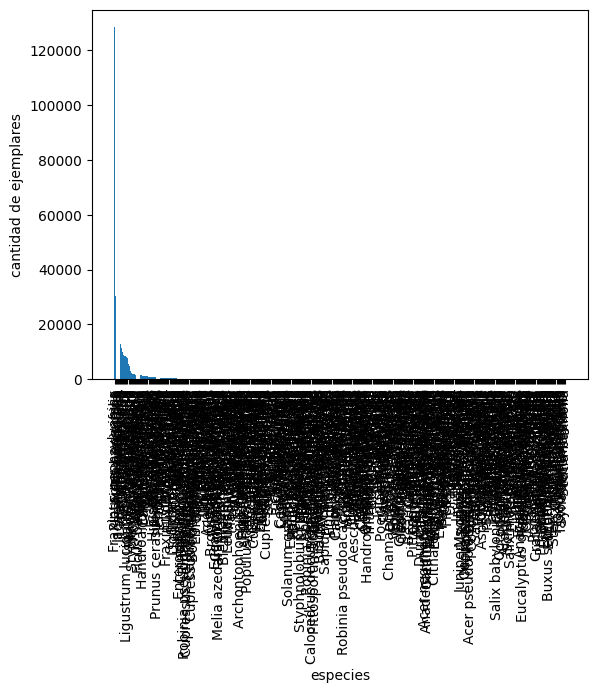

In [ ]:
nombres= datos_arbolado['nombre_cientifico'].value_counts().index
cantidad= datos_arbolado['nombre_cientifico'].value_counts().values

plt.bar(nombres,cantidad)
plt.xlabel('especies')
plt.xticks(rotation=90)
plt.ylabel('cantidad de ejemplares')
plt.show()

Claramente hay muchas especies :). Mejor tomemos el top 20. dado que el resto comienzan a tener valores mucho menores que representan poca fraccion del total.

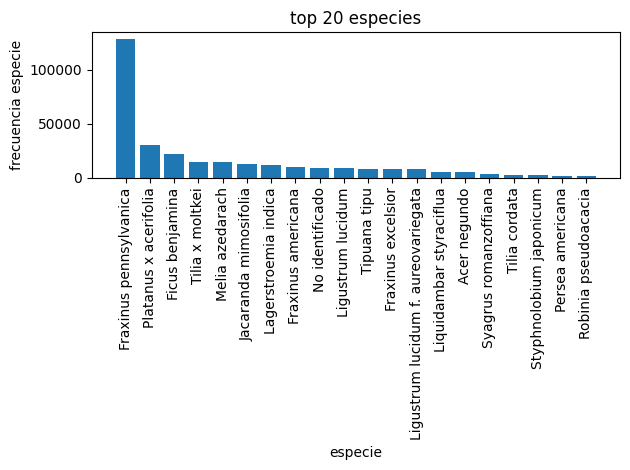

In [ ]:


top20= datos_arbolado['nombre_cientifico'].value_counts().nlargest(20)
nombre= top20.index
conteo= top20.values

plt.Figure(figsize=(12,7))

plt.bar(nombre,conteo)
plt.title('top 20 especies')
plt.ylabel('frecuencia especie')
#plt.yscale('log')
plt.xlabel('especie')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Ahora si, esta mas lindo. **Ahora nos queda decidir que hacemos con el resto de especies. nosotros planteamos convertirlas en una categoria llamada "Otra"**

In [ ]:
datos_arbolado[datos_arbolado['nombre_cientifico']=='No identificado']
datos_arbolado['nombre_cientifico']= datos_arbolado['nombre_cientifico'].replace('No identificado')

nombres= nombre.to_list()
datos_arbolado['nombre_cientifico']=np.where(datos_arbolado['nombre_cientifico'].isin(nombres), datos_arbolado['nombre_cientifico'], 'Otra')
datos_arbolado['nombre_cientifico'].value_counts()


/tmp/ipykernel_110254/2379346614.py:2: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  datos_arbolado['nombre_cientifico']= datos_arbolado['nombre_cientifico'].replace('No identificado')


nombre_cientifico
Fraxinus pennsylvanica                 131485
Otra                                    46184
Platanus x acerifolia                   31091
Ficus benjamina                         22212
Tilia x moltkei                         15165
Melia azedarach                         14518
Jacaranda mimosifolia                   13259
Lagerstroemia indica                    11855
Fraxinus americana                       9988
Ligustrum lucidum                        8905
Tipuana tipu                             8492
Fraxinus excelsior                       8458
Ligustrum lucidum f. aureovariegata      7948
Liquidambar styraciflua                  5540
Acer negundo                             5097
Syagrus romanzoffiana                    3247
Tilia cordata                            2162
Styphnolobium japonicum                  2131
Persea americana                         2003
Robinia pseudoacacia                     1921
Name: count, dtype: int64

Que pasa si mostramos en el mapa las especies, hay algun patron?

/tmp/ipykernel_110254/757862515.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


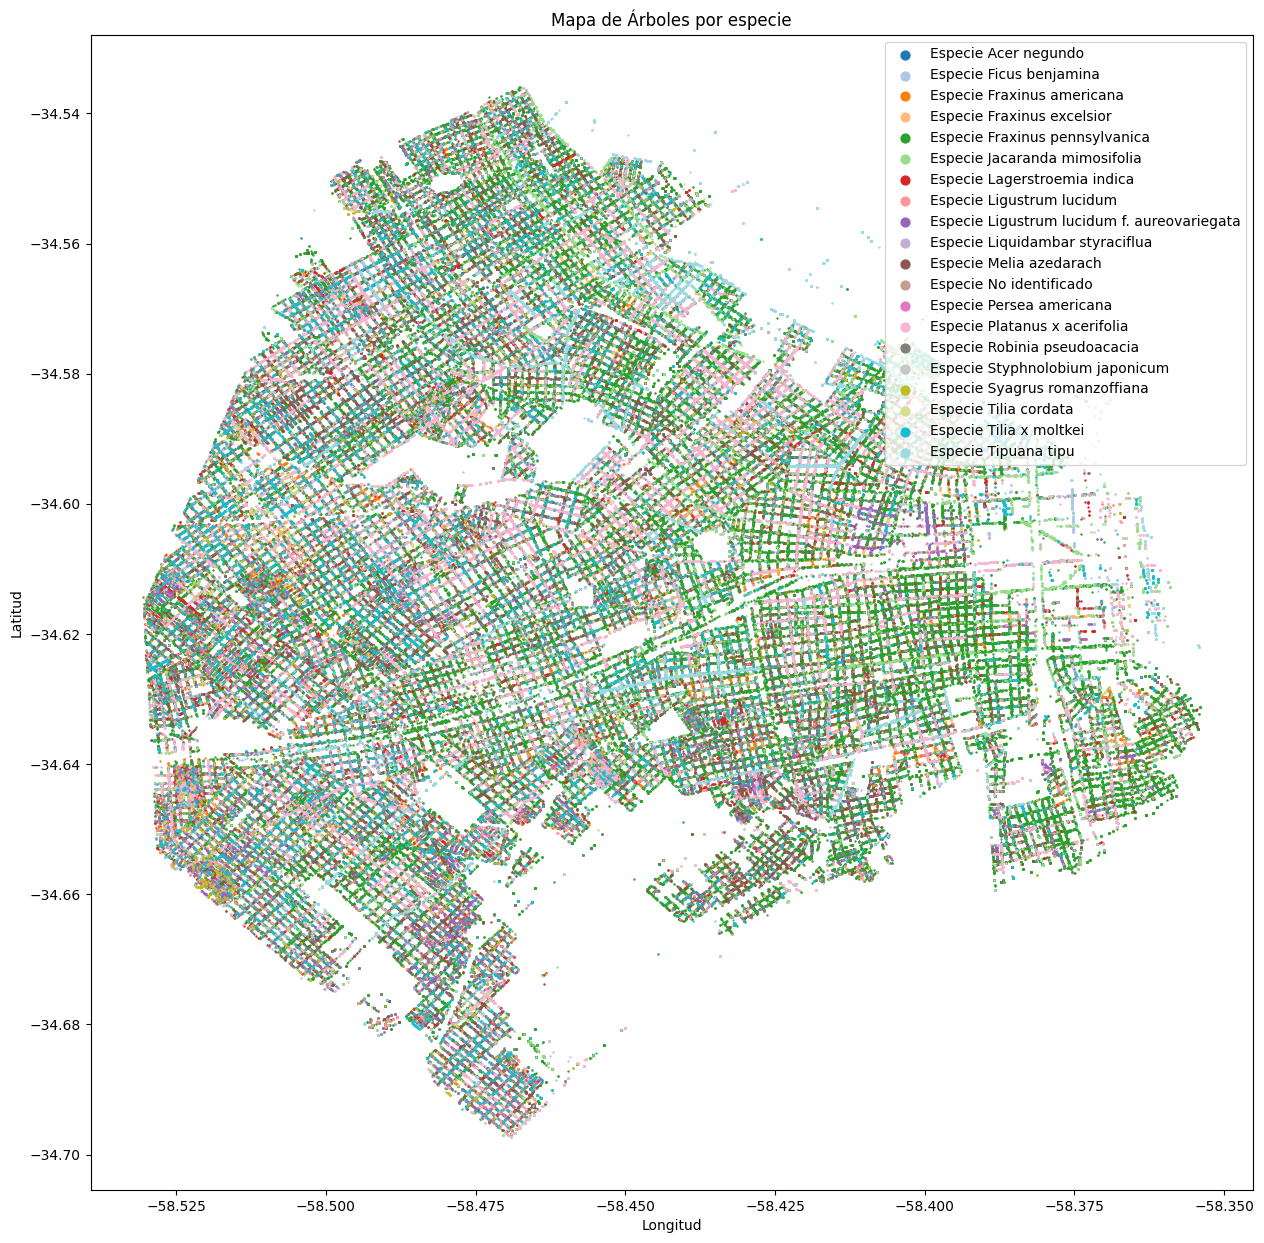

In [ ]:


plt.figure(figsize=(15, 15))
categorias = sorted(top20.index)
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, especie in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['nombre_cientifico'] == especie]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=0.5,
        color=colores(i),
        label=f'Especie {(especie)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por especie")
plt.legend(markerscale=9)
plt.show()

No se ve nada claro la verdad :(, pero Fraxinus pensilvanica es la especie dominante por diferencia, puedo salir algun analisis interesante de ahi..

## Ancho_acera
ancho en metros de la acera donde esta plantado el arbol

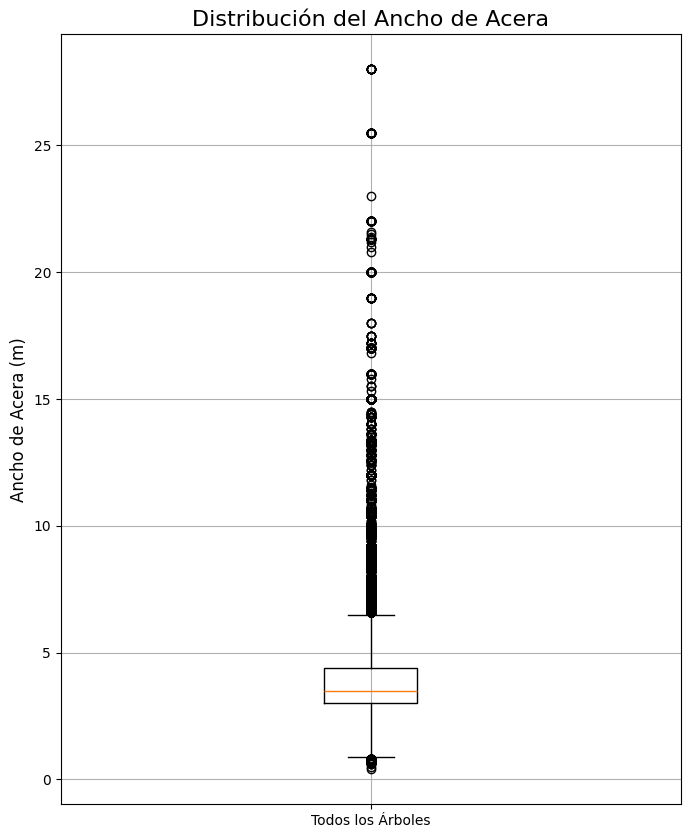

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.DataFrame()
datos_arbolado['ancho_acera'] = datos_arbolado['ancho_acera'].astype(str).str.replace(',', '.')

# Convertimos a numérico. 
datos_arbolado['ancho_acera'] = pd.to_numeric(datos_arbolado['ancho_acera'], errors='coerce')


# creamos el grafico
fig, ax = plt.subplots(figsize=(8, 10))

# Usamos la columna limpia y .dropna() para eliminar los NaN
ax.boxplot(datos_arbolado['ancho_acera'].dropna())

ax.set_title('Distribución del Ancho de Acera', fontsize=16)
ax.set_ylabel('Ancho de Acera (m)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles'])
ax.grid(True)

plt.show()

Aca vemos que hay muchos outliers. me imagino que algunos son de avenidas o calles especiales, pero mas de 20 metros? me parece mucho, hay que investigarlos.

#### Valores extremos minimos
Vamos a analisar en que calles mas se repite y busquemos esas calles en google maps para ver si efectivamente son asi de chicas

In [ ]:

datos_arbolado[datos_arbolado['ancho_acera']<1]['calle_nombre'].value_counts()

calle_nombre
Crámer                       97
Fernández Espiro Diego       13
Gutenberg                     8
Sumaca Santísima Trinidad     8
Plaza                         8
Zeballos Estanislao           3
Santiago Costamagna           2
Pérez Galdós Benito Av.       1
Suárez                        1
Ochoa Enrique                 1
Azurduy Juana                 1
Tres Arroyos                  1
Yerbal                        1
Acassuso                      1
San Mateo                     1
Güemes                        1
Amenábar                      1
Conesa                        1
Name: count, dtype: int64

la calle cramer es la que mas se repite en los que tienen acera chica, eso se debe a que la calle tiene una parte donde da junto a la via, y esa acera es muy pequeña.
**son caso particulares de ciertos sectores donde por diferentes causas las aceras son mas pequeñas, por lo tanto se toma la decicion de eliminarlos**

In [ ]:
datos_arbolado=datos_arbolado[datos_arbolado['ancho_acera']>1]

#### Valores extremos altos

In [ ]:
datos_arbolado[datos_arbolado['ancho_acera']>9]

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
43,-58.382926,-34.593509,1.0,Cerrito,1200.0,12500,Fraxinus pennsylvanica,10.8,Ocupada,Fuera de línea,A nivel,45.0,11.0
44,-58.382920,-34.593640,1.0,Cerrito,1200.0,12480,Fraxinus pennsylvanica,10.0,Ocupada,Fuera de línea,A nivel,30.0,10.0
45,-58.382920,-34.593640,1.0,Cerrito,1200.0,12480,Otra,10.0,Ocupada,Regular,A nivel,2.0,20.0
46,-58.382916,-34.593718,1.0,Cerrito,1200.0,12400,Fraxinus pennsylvanica,10.0,Ocupada,Fuera de línea,A nivel,50.0,12.0
223,-58.382370,-34.601919,1.0,Cerrito,500.0,5620,Jacaranda mimosifolia,10.0,Ocupada,Regular,Elevada,24.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
368252,-58.417944,-34.554515,14.0,Obligado Rafael Av. Costanera,4800.0,<NA>,Tipuana tipu,13.3,Ocupada,Regular,A nivel,29.0,8.0
368253,-58.410430,-34.558270,14.0,Obligado Rafael Av. Costanera,3800.0,<NA>,Tipuana tipu,13.3,Ocupada,Regular,A nivel,4.0,2.0
368298,-58.417944,-34.554515,14.0,Obligado Rafael Av. Costanera,4800.0,<NA>,Tipuana tipu,14.3,Ocupada,Regular,A nivel,28.0,9.0
368365,-58.413925,-34.566584,14.0,Roldán Belisario Av.,4600.0,<NA>,Otra,13.0,Ocupada,Fuera de línea,A nivel,45.0,14.0


El numero de ejemplares con mas de 9 metros de acera representa menos del 1%, y queremos enfocar nuestro estudio en calles dentro de todo normales, quitando las avenidas o de mal escritura de los datos. ya que representan casos especiales.

In [ ]:
datos_arbolado= datos_arbolado[datos_arbolado['ancho_acera']<=9]

{'whiskers': [<matplotlib.lines.Line2D at 0x779cba56b6e0>,
 'caps': [<matplotlib.lines.Line2D at 0x779cba536e70>,
 'boxes': [<matplotlib.lines.Line2D at 0x779cba57f710>],
 'medians': [<matplotlib.lines.Line2D at 0x779cba525a30>],
 'fliers': [<matplotlib.lines.Line2D at 0x779cba523da0>],
 'means': []}

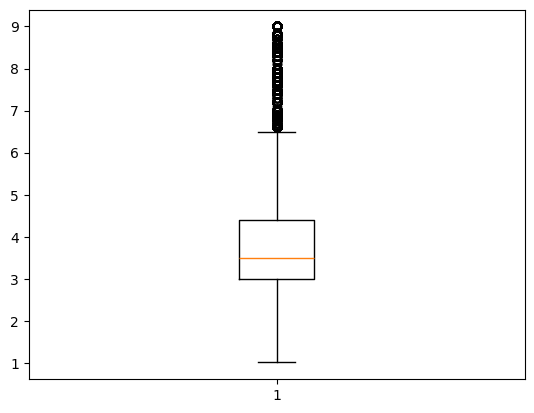

In [ ]:
plt.boxplot(datos_arbolado['ancho_acera'])

In [ ]:
datos_arbolado


,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,Esmeralda,1000.0,11200,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,1.0,Pellegrini Carlos,1300.0,13450,Otra,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,1.0,Arroyo,800.0,8480,Fraxinus pennsylvanica,4.0,Ocupada,Regular,A nivel,7.0,6.0
5,-58.381043,-34.591584,1.0,Arroyo,900.0,9700,Fraxinus pennsylvanica,3.5,Ocupada,Regular,A nivel,29.0,15.0
6,-58.380968,-34.591576,1.0,Arroyo,900.0,9620,Fraxinus pennsylvanica,4.5,Ocupada,Regular,A nivel,21.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
370051,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,83.0,20.0
370052,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,76.0,20.0
370053,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,85.0,20.0
370054,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,84.0,20.0


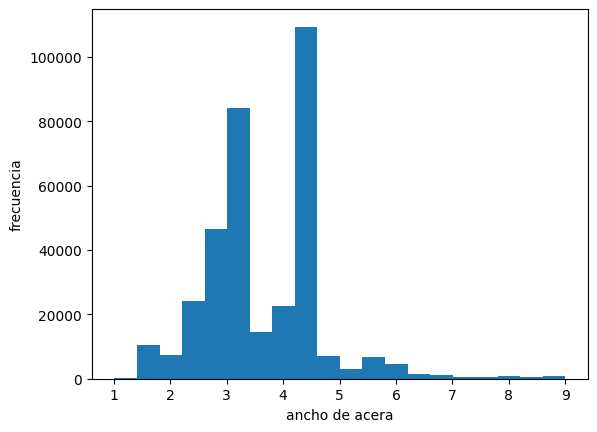

In [ ]:
bins=20

plt.hist(datos_arbolado['ancho_acera'], bins=bins)
plt.xlabel('ancho de acera')
plt.ylabel('frecuencia')
plt.show()

## Estado_plantera
Representa la situacion de la plantera donde esta plantado el arbol.
Puede ser:
* Vacia
* Subocupada
* Ocupada
* Sobreocupada

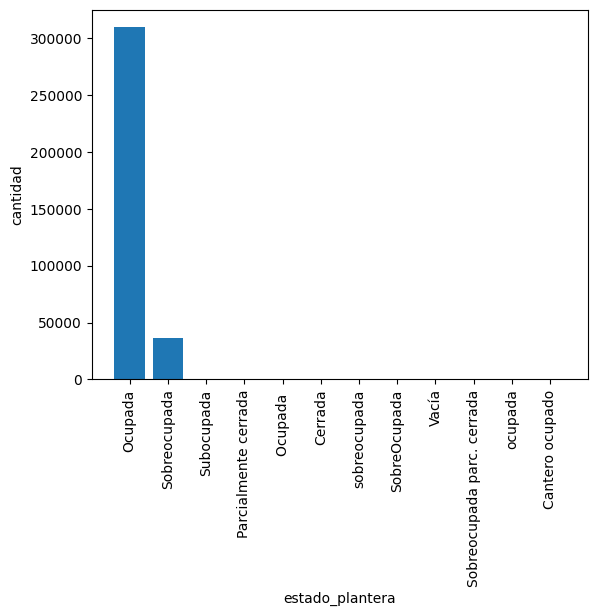

In [ ]:
estados= datos_arbolado['estado_plantera'].value_counts().index
valores= datos_arbolado['estado_plantera'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("estado_plantera")
plt.xticks(rotation=90)

plt.ylabel("cantidad")
plt.show()


Hay Estados mal escritos. como son pocos los mapeo con un diccionario.

In [ ]:
datos_arbolado['estado_plantera']= datos_arbolado['estado_plantera'].str.lower()


In [ ]:
dic= {
    'vacía': 0,
    'subocupada':1,
    'ocupada': 2,
    'sobreocupada': 3
}
datos_arbolado['estado_plantera']=datos_arbolado['estado_plantera'].map(dic)
cantidad= datos_arbolado['estado_plantera'].value_counts()
clase_plantera= datos_arbolado['estado_plantera']


In [ ]:

print(datos_arbolado['estado_plantera'].value_counts())
print(datos_arbolado['estado_plantera'].isna().sum())

estado_plantera
2.0    309705
3.0     36108
1.0       491
0.0         3
Name: count, dtype: int64
158


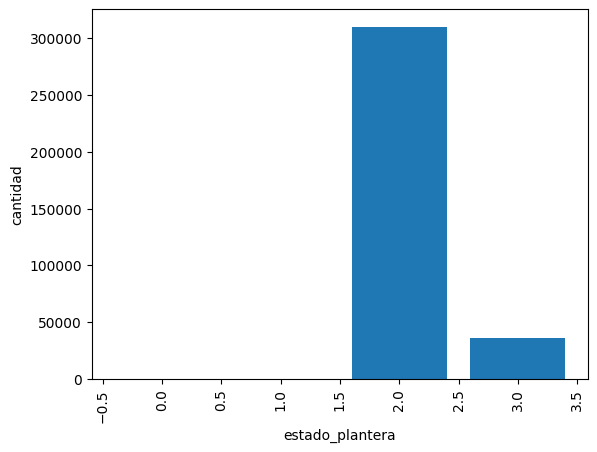

In [ ]:
estados= datos_arbolado['estado_plantera'].value_counts().index
valores= datos_arbolado['estado_plantera'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("estado_plantera")
plt.xticks(rotation=90)

plt.ylabel("cantidad")
plt.show()


## Ubicacion_plantera
Representa la ubicacion donde se puso la plantera, puede ser ochava (esquina), normal (regular), o fuera de linea

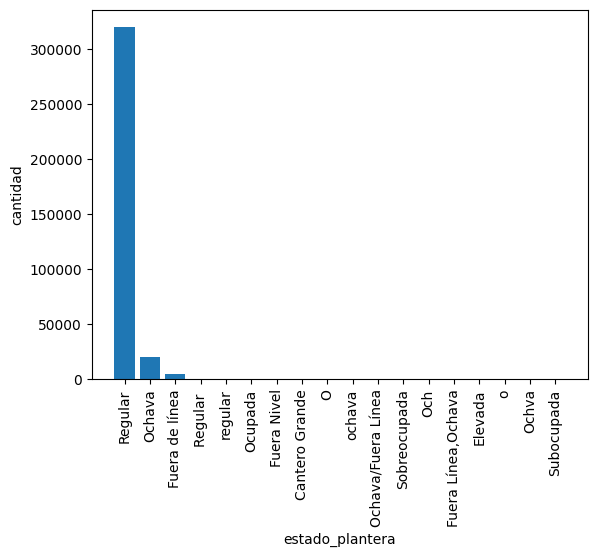

In [ ]:
estados=datos_arbolado['ubicacion_plantera'].value_counts().index
valores= datos_arbolado['ubicacion_plantera'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("estado_plantera")
plt.xticks(rotation=90)

plt.ylabel("cantidad")
plt.show()

Al igual que estado_plantera, hay que mapear a valores correctos, y eliminar los que no tienen sentido como sobreocupada.

In [ ]:

datos_arbolado['ubicacion_plantera']=datos_arbolado['ubicacion_plantera'].str.lower()
datos_arbolado['ubicacion_plantera'].value_counts()

mapeo_limpieza = {
    'regular': 'Regular',
    'ochava': 'Ochava',
    'o': 'Ochava',
    'och': 'Ochava',       
    'ochva': 'Ochava',    
    'fuera de línea': 'Fuera de linea'
}
datos_arbolado['ubicacion_plantera']= datos_arbolado['ubicacion_plantera'].map(mapeo_limpieza)
print(datos_arbolado['ubicacion_plantera'].value_counts())

ubicacion_plantera
Regular           320024
Ochava             20826
Fuera de linea      4751
Name: count, dtype: int64


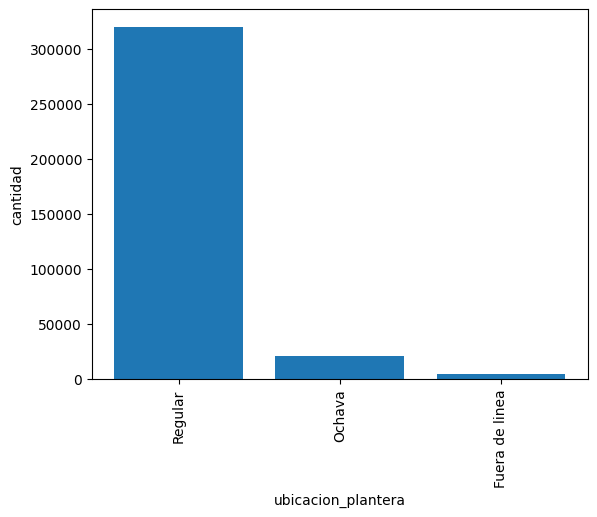

In [ ]:
estados=datos_arbolado['ubicacion_plantera'].value_counts().index
valores= datos_arbolado['ubicacion_plantera'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("ubicacion_plantera")
plt.xticks(rotation=90)

plt.ylabel("cantidad")
plt.show()

## Nivel_plantera
Marca el nivel en altutitud de la plantera. puede ser:
* Bajo nivel
* A nivel
* Elevada

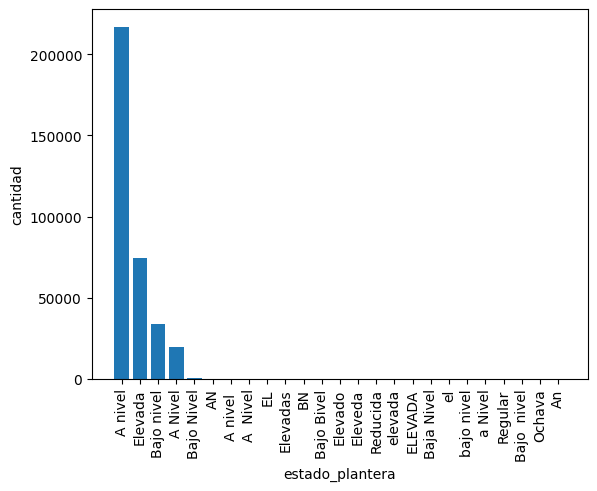

In [ ]:
estados=datos_arbolado['nivel_plantera'].value_counts().index
valores= datos_arbolado['nivel_plantera'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("estado_plantera")
plt.xticks(rotation=90)

plt.ylabel("cantidad")
plt.show()

Ocurre lo mismo que las 2 anteriores. hay algunos despistados al cargar los datos.

In [ ]:
datos_arbolado['nivel_plantera']= datos_arbolado['nivel_plantera'].str.lower().str.strip()
print(datos_arbolado['nivel_plantera'].value_counts())

nivel_plantera
a nivel        236514
elevada         74234
bajo nivel      34843
an                 86
a  nivel           32
el                 22
elevadas           18
bn                 12
bajo bivel          9
elevado             5
reducida            5
eleveda             5
baja nivel          2
regular             1
ochava              1
bajo  nivel         1
Name: count, dtype: int64


In [ ]:

mapeo_ordinal = {
    # Nivel 0: Bajo Nivel
    'bajo nivel': 0,
    'bajo bivel': 0,
    'baja nivel': 0,
    'bajo  nivel': 0,
    'bn': 0,

    # Nivel 1: A Nivel (el estándar)
    'a nivel': 1,
    'a  nivel': 1,
    'an': 1,
    'a nvel': 1, # (Asumimos posibles typos)
    
    # Nivel 2: Elevada
    'elevada': 2,
    'elevado': 2,
    'elevadas': 2,
    'eleveda': 2,
    'el': 2,
    'elevada': 2
}
datos_arbolado['nivel_plantera']= datos_arbolado['nivel_plantera'].map(mapeo_ordinal)
print(datos_arbolado['nivel_plantera'].value_counts())

nivel_plantera
1.0    236632
2.0     74284
0.0     34867
Name: count, dtype: int64


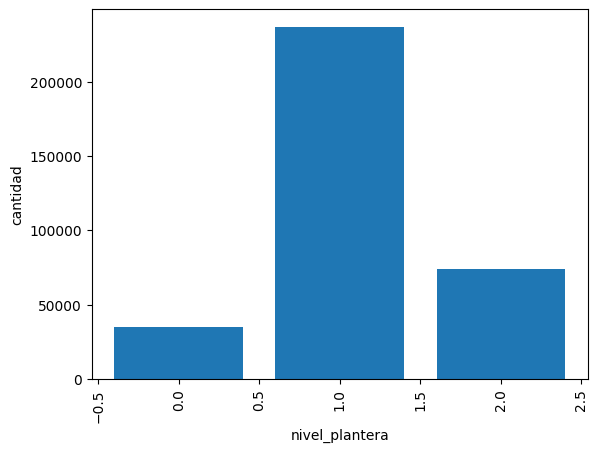

In [ ]:
estados=datos_arbolado['nivel_plantera'].value_counts().index
valores= datos_arbolado['nivel_plantera'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("nivel_plantera")
plt.xticks(rotation=90)

plt.ylabel("cantidad")
plt.show()

## Diametro_altura_pecho

Representa el diametro del arbol, a la altura del pecho del que mide.

(array([4.7858e+04, 5.5866e+04, 7.5466e+04, 6.3181e+04, 3.9291e+04,
        2.5045e+04, 1.8689e+04, 1.0790e+04, 5.7370e+03, 2.1980e+03,
        1.1070e+03, 4.7800e+02, 2.4700e+02, 9.8000e+01, 4.4000e+01,
        3.9000e+01, 2.9000e+01, 1.2000e+01, 1.3000e+01, 1.6000e+01]),
 array([  0. ,   9.9,  19.8,  29.7,  39.6,  49.5,  59.4,  69.3,  79.2,
         89.1,  99. , 108.9, 118.8, 128.7, 138.6, 148.5, 158.4, 168.3,
        178.2, 188.1, 198. ]),
 <BarContainer object of 20 artists>)

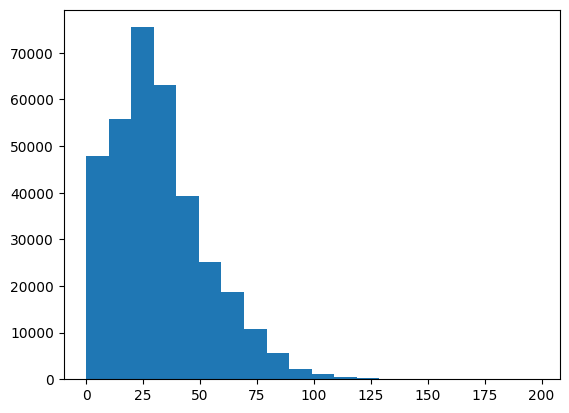

In [ ]:
plt.hist(datos_arbolado['diametro_altura_pecho'], bins=20)

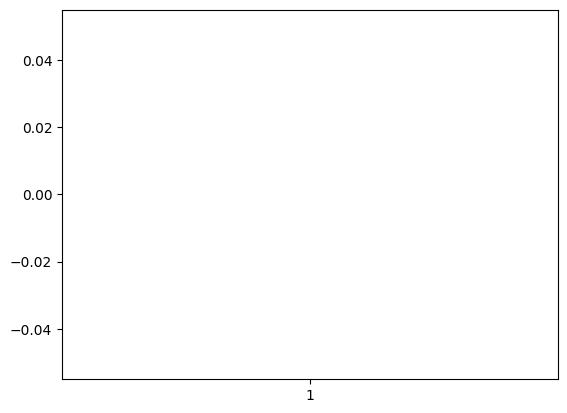

In [ ]:
plt.boxplot(datos_arbolado['diametro_altura_pecho'])
plt.show()

Claro hay nulos.

In [ ]:
datos_arbolado['diametro_altura_pecho'].isna().value_counts()

diametro_altura_pecho
False    346204
True        261
Name: count, dtype: int64

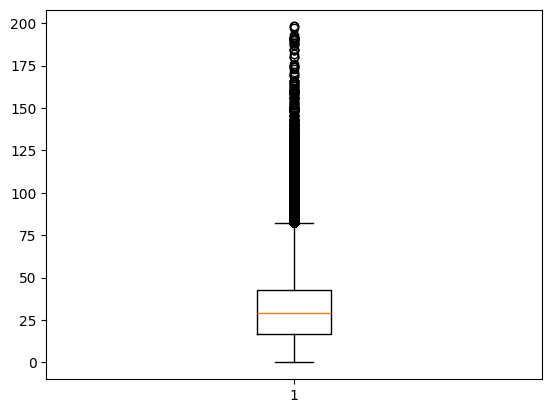

In [ ]:
plt.boxplot(datos_arbolado['diametro_altura_pecho'].dropna())
plt.show()

#### Analizamos los valores extremos altos

In [ ]:
datos_arbolado[datos_arbolado['diametro_altura_pecho']>80].count()

long                     8732
lat                      8732
comuna                   8732
calle_nombre             8732
calle_altura             8732
calle_chapa              8586
nombre_cientifico        8732
ancho_acera              8732
estado_plantera          8728
ubicacion_plantera       8705
nivel_plantera           8713
diametro_altura_pecho    8732
altura_arbol             8706
dtype: int64

In [ ]:
outliers_diametro= datos_arbolado[datos_arbolado['diametro_altura_pecho']>100]
outliers_diametro['calle_nombre'].value_counts()

calle_nombre
Morán Pedro                       23
Elcano Av.                        18
La Pampa                          17
Quesada                           17
Figueroa Alcorta Presidente Av    16
                                  ..
Martínez Rosas                     1
Guzmán Av.                         1
García Teodoro                     1
Leiva                              1
Moreno                             1
Name: count, Length: 600, dtype: int64

In [ ]:
outliers_diametro[outliers_diametro['calle_nombre']=='Morán Pedro']

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
173178,-58.529298,-34.613955,10.0,Morán Pedro,5400.0,54960,Persea americana,4.4,3.0,Regular,2.0,153.0,12.0
216585,-58.526380,-34.611682,11.0,Morán Pedro,5200.0,52330,Otra,4.4,2.0,Regular,1.0,105.0,13.0
219444,-58.526988,-34.612098,11.0,Morán Pedro,5200.0,52690,Ficus benjamina,4.4,2.0,Regular,2.0,105.0,11.0
225499,-58.518688,-34.606558,11.0,Morán Pedro,4600.0,46870,Otra,4.4,2.0,Ochava,1.0,108.0,20.0
226369,-58.522047,-34.608809,11.0,Morán Pedro,4900.0,49180,Platanus x acerifolia,4.4,2.0,Regular,2.0,105.0,12.0
226692,-58.522317,-34.608994,11.0,Morán Pedro,4900.0,49700,Platanus x acerifolia,4.4,2.0,Regular,1.0,105.0,14.0
332448,-58.499110,-34.594557,15.0,Morán Pedro,3100.0,31200,Platanus x acerifolia,5.4,2.0,Regular,1.0,127.0,21.0
332455,-58.499682,-34.594911,15.0,Morán Pedro,3100.0,31660,Platanus x acerifolia,5.4,2.0,Regular,2.0,198.0,22.0
332624,-58.499214,-34.594622,15.0,Morán Pedro,3100.0,31300,Platanus x acerifolia,5.4,3.0,Regular,2.0,115.0,27.0
333298,-58.499531,-34.594817,15.0,Morán Pedro,3100.0,31560,Platanus x acerifolia,5.4,2.0,Regular,1.0,150.0,17.0


In [ ]:
outliers_diametro[outliers_diametro['calle_nombre']=='Elcano Av.']

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
344664,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,108.0,30.0
344717,-58.466458,-34.590663,15.0,Elcano Av.,4700.0,47000,Tipuana tipu,4.4,2.0,Regular,1.0,126.0,20.0
344718,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.4,2.0,Ochava,1.0,115.0,20.0
344719,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,110.0,20.0
344720,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,104.0,21.0
344765,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,110.0,21.0
344768,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,115.0,20.0
344769,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,108.0,21.0
344770,-58.459804,-34.576157,13.0,Elcano Av.,3400.0,34500,Tipuana tipu,4.8,2.0,Regular,1.0,101.0,21.0
344771,-58.462262,-34.586580,15.0,Elcano Av.,4300.0,43500,Tipuana tipu,4.8,2.0,Regular,1.0,104.0,21.0


In [ ]:
datos_arbolado['diametro_altura_pecho'].describe()

count    346204.000000
mean         31.862971
std          21.075280
min           0.000000
25%          17.000000
50%          29.000000
75%          43.000000
max         198.000000
Name: diametro_altura_pecho, dtype: float64

In [ ]:
datos_arbolado[datos_arbolado['diametro_altura_pecho']>110].count()


long                     818
lat                      818
comuna                   818
calle_nombre             818
calle_altura             818
calle_chapa              801
nombre_cientifico        818
ancho_acera              818
estado_plantera          818
ubicacion_plantera       814
nivel_plantera           816
diametro_altura_pecho    818
altura_arbol             815
dtype: int64

**Se toma la decicion de eliminar los que tengan diametro mayor a 100, dado que en varios se busco por google maps con street view fotos del lugar y no se veian de ese tamaño, ademas al ser pequeña un cantidad no afecta el analisis y son casos especiales**


In [ ]:
datos_arbolado= datos_arbolado[datos_arbolado['diametro_altura_pecho']<110]


In [ ]:
datos_arbolado['diametro_altura_pecho'].isna().sum()

np.int64(0)

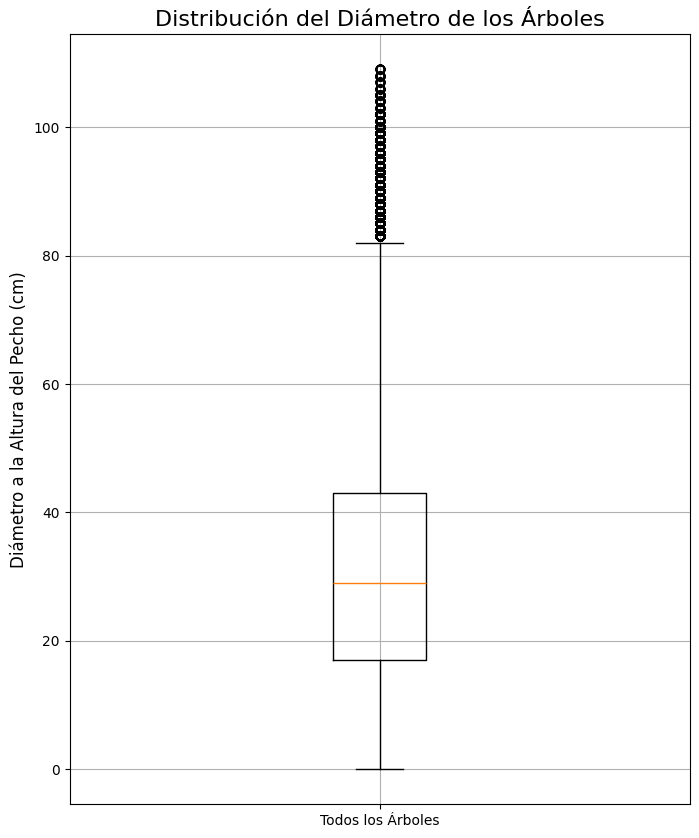

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(8, 10))

ax.boxplot(datos_arbolado['diametro_altura_pecho'])


ax.set_title('Distribución del Diámetro de los Árboles', fontsize=16)
ax.set_ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles'])
ax.grid(True)

plt.show()

In [ ]:
datos_arbolado[datos_arbolado['diametro_altura_pecho']<2]

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
60,-58.379075,-34.592834,1.0,Juncal,800.0,8370,Fraxinus pennsylvanica,2.6,3.0,Regular,1.0,1.0,2.0
107,-58.369818,-34.600521,1.0,Tucumán,100.0,1330,Jacaranda mimosifolia,3.9,2.0,Regular,1.0,0.0,NaN
128,-58.389326,-34.604797,1.0,Montevideo,300.0,3570,Ficus benjamina,2.1,2.0,Regular,1.0,0.0,NaN
274,-58.387045,-34.590935,1.0,Montevideo,1600.0,16930,Ficus benjamina,2.8,2.0,Regular,1.0,0.0,NaN
310,-58.388808,-34.621140,1.0,Cevallos Virrey,1000.0,10870,Jacaranda mimosifolia,2.8,2.0,Regular,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
368486,-58.411091,-34.585233,14.0,Salguero Jerónimo,2300.0,<NA>,Otra,3.2,2.0,Regular,1.0,1.0,2.0
368632,-58.468939,-34.589146,15.0,Punta Arenas Av.,1100.0,1115,Otra,2.5,2.0,Regular,1.0,0.0,NaN
368641,-58.468939,-34.589146,15.0,Punta Arenas Av.,1100.0,1115,Platanus x acerifolia,2.5,2.0,Regular,1.0,0.0,2.0
368773,-58.471758,-34.599781,15.0,Punta Arenas Av.,1600.0,1629,Lagerstroemia indica,4.4,2.0,Regular,1.0,1.0,2.0


Lo mismo decidimos con los valores extremos bajos. tomamos mayor a 2 cm.

In [ ]:
datos_arbolado= datos_arbolado[datos_arbolado['diametro_altura_pecho']>=2]

In [ ]:
datos_arbolado.to_pickle('../data/datos_arbolado')

In [ ]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336655 entries, 0 to 370055
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   336655 non-null  float64
 1   lat                    336655 non-null  float64
 2   comuna                 336655 non-null  float64
 3   calle_nombre           336655 non-null  object 
 4   calle_altura           336655 non-null  float64
 5   calle_chapa            333391 non-null  Int32  
 6   nombre_cientifico      336655 non-null  object 
 7   ancho_acera            336655 non-null  float64
 8   estado_plantera        336506 non-null  float64
 9   ubicacion_plantera     335825 non-null  object 
 10  nivel_plantera         336011 non-null  float64
 11  diametro_altura_pecho  336655 non-null  float64
 12  altura_arbol           335516 non-null  float64
dtypes: Int32(1), float64(9), object(3)
memory usage: 35.0+ MB


## Altura_arbol
Representa la altura de cada arbol

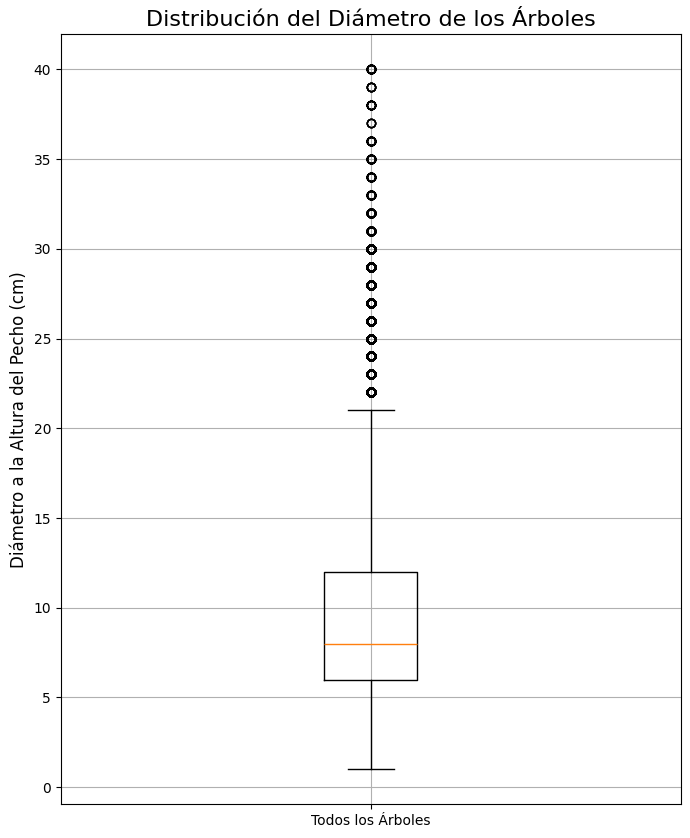

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(8, 10))

ax.boxplot(datos_arbolado['altura_arbol'].dropna())


ax.set_title('Distribución del Diámetro de los Árboles', fontsize=16)
ax.set_ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles'])
ax.grid(True)

plt.show()

In [ ]:
datos_arbolado[datos_arbolado['altura_arbol'].isna()]

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
146,-58.373793,-34.603668,1.0,San Martín,300.0,3670,Otra,1.8,2.0,Regular,1.0,3.0,NaN
1758,-58.378500,-34.604746,1.0,Sarmiento,800.0,8330,Otra,3.2,2.0,Regular,1.0,3.0,NaN
3427,-58.374662,-34.606872,1.0,Mitre Bartolomé,500.0,5620,Otra,3.0,2.0,Regular,1.0,3.0,NaN
4007,-58.370227,-34.600462,1.0,Além Leandro N. Av.,600.0,6190,Platanus x acerifolia,5.0,2.0,Ochava,1.0,2.0,NaN
4105,-58.366890,-34.615635,1.0,Chile,0.0,190,Platanus x acerifolia,3.8,2.0,Regular,1.0,7.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
364247,-58.505831,-34.564989,12.0,Aizpurúa,3800.0,<NA>,Acer negundo,2.4,2.0,Regular,1.0,67.0,NaN
364250,-58.505831,-34.564989,12.0,Aizpurúa,3800.0,<NA>,Acer negundo,3.6,2.0,Regular,1.0,38.0,NaN
364258,-58.505831,-34.564989,12.0,Aizpurúa,3800.0,<NA>,Acer negundo,2.4,2.0,Regular,1.0,48.0,NaN
367670,-58.423058,-34.571056,14.0,"Del Libertador, Av",3900.0,<NA>,Tipuana tipu,4.0,2.0,Regular,1.0,100.0,NaN


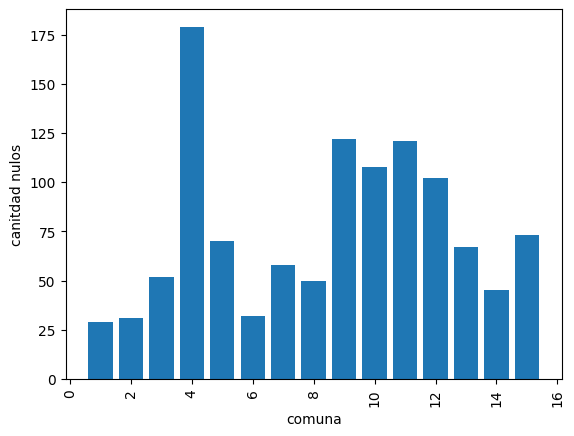

In [ ]:



estados=datos_arbolado[datos_arbolado['altura_arbol'].isna()]['comuna'].value_counts().index
valores= datos_arbolado[datos_arbolado['altura_arbol'].isna()]['comuna'].value_counts().values

plt.bar(estados,valores)
plt.xlabel("comuna")
plt.xticks(rotation=90)

plt.ylabel("canitdad nulos")
plt.show()

In [ ]:
datos_arbolado= datos_arbolado[datos_arbolado['altura_arbol'].notna()]


**Se obta por eliminar los casos donde la altura es nula.**

In [ ]:
datos_arbolado['altura_arbol'].isna().sum()

np.int64(0)

In [ ]:
datos_arbolado[datos_arbolado['altura_arbol']>39]

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
90,-58.381536,-34.592402,1.0,Pellegrini Carlos,1300.0,13370,Otra,4.5,2.0,Regular,2.0,3.0,40.0
28042,-58.394735,-34.613740,3.0,Sarandí,300.0,3850,Fraxinus pennsylvanica,3.0,2.0,Regular,0.0,19.0,40.0
76626,-58.443372,-34.608020,6.0,Díaz Vélez Av.,5400.0,54770,Platanus x acerifolia,6.0,2.0,Regular,2.0,35.0,40.0
95653,-58.436798,-34.637094,7.0,Castañares Av.,1300.0,13100,Jacaranda mimosifolia,6.0,3.0,Regular,2.0,54.0,40.0
110799,-58.455935,-34.621240,6.0,Avellaneda Av.,1800.0,1800,Platanus x acerifolia,4.0,2.0,Ochava,0.0,64.0,40.0
110800,-58.455935,-34.621240,6.0,Avellaneda Av.,1800.0,1800,Platanus x acerifolia,5.5,2.0,Ochava,1.0,57.0,40.0
110801,-58.455935,-34.621240,6.0,Avellaneda Av.,1800.0,1800,Platanus x acerifolia,5.5,2.0,Ochava,0.0,41.0,40.0
110802,-58.455935,-34.621240,6.0,Avellaneda Av.,1800.0,1800,Platanus x acerifolia,5.5,2.0,Regular,0.0,41.0,40.0
110805,-58.455935,-34.621240,6.0,Avellaneda Av.,1800.0,1800,Platanus x acerifolia,5.5,2.0,Regular,1.0,41.0,40.0
110811,-58.455935,-34.621240,6.0,Avellaneda Av.,1800.0,1800,Platanus x acerifolia,5.5,2.0,Regular,1.0,57.0,40.0


**Por el momento los outliers se dejan parecen ser datos reales, y que pueden servir para analizar mas adelante.**

In [ ]:
datos_arbolado.to_pickle('../data/datos_arbolado')

## Relacion ancho acera con estado plantera sobreocupada

In [ ]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335516 entries, 0 to 370055
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   335516 non-null  float64
 1   lat                    335516 non-null  float64
 2   comuna                 335516 non-null  float64
 3   calle_nombre           335516 non-null  object 
 4   calle_altura           335516 non-null  float64
 5   calle_chapa            332263 non-null  Int32  
 6   nombre_cientifico      335516 non-null  object 
 7   ancho_acera            335516 non-null  float64
 8   estado_plantera        335367 non-null  float64
 9   ubicacion_plantera     334690 non-null  object 
 10  nivel_plantera         334874 non-null  float64
 11  diametro_altura_pecho  335516 non-null  float64
 12  altura_arbol           335516 non-null  float64
dtypes: Int32(1), float64(9), object(3)
memory usage: 34.9+ MB


In [ ]:
datos_arbolado.to_pickle('../data/datos_arbolado')

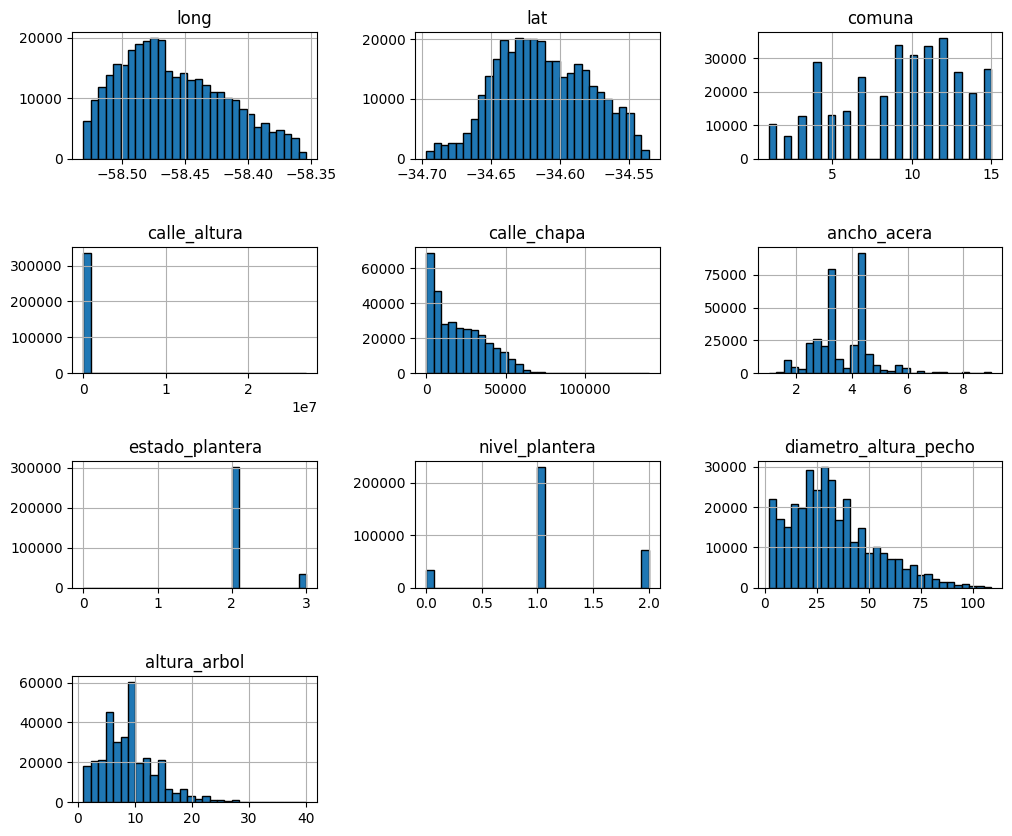

In [ ]:
datos_arbolado.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

# Hipotesis 1

In [ ]:
datos_arbolado = pd.read_pickle("../data/datos_arbolado")

datos_arbolado.head()

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,Esmeralda,1000.0,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,Pellegrini Carlos,1300.0,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,Arroyo,800.0,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,Arroyo,900.0,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,Arroyo,900.0,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


#### Distribibucion absoluta de arboles

Text(0, 0.5, 'Cantidad arboles')

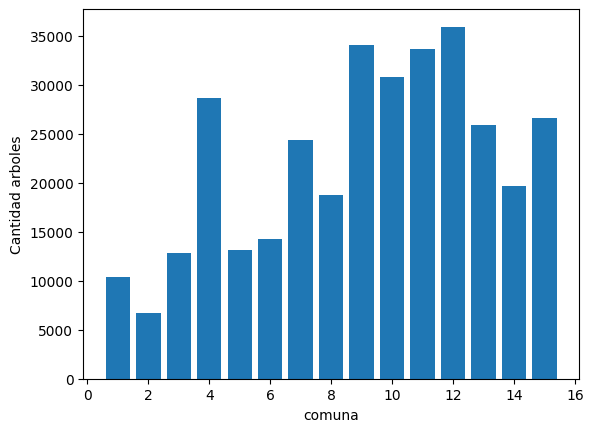

In [ ]:
cant_arb= datos_arbolado['comuna'].value_counts()
plt.bar(cant_arb.index, cant_arb.values)
plt.xlabel('comuna')
plt.ylabel('Cantidad arboles')


--- Densidad TOTAL de árboles por comuna (árboles/km²) ---
        densidad_total_arboles  total_arboles  superficie_km2  \
comuna                                                          
10.0               2425.354331          30802            12.7   
11.0               2383.617021          33609            14.1   
15.0               2353.097345          26590            11.3   
4.0                2312.500000          28675            12.4   
12.0               2301.346154          35901            15.6   
6.0                2102.205882          14295             6.8   
9.0                2050.120482          34032            16.6   
3.0                2029.682540          12787             6.3   
7.0                1965.483871          24372            12.4   
5.0                1954.477612          13095             6.7   
13.0               1772.739726          25882            14.6   
2.0                1103.278689           6730             6.1   
14.0               1029.057592

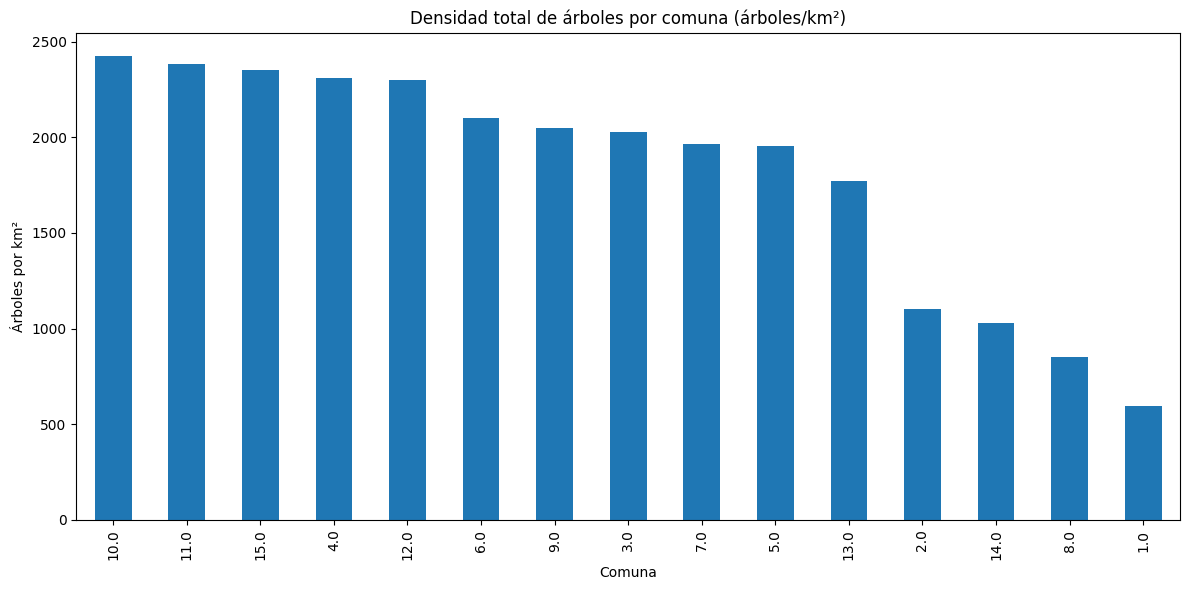

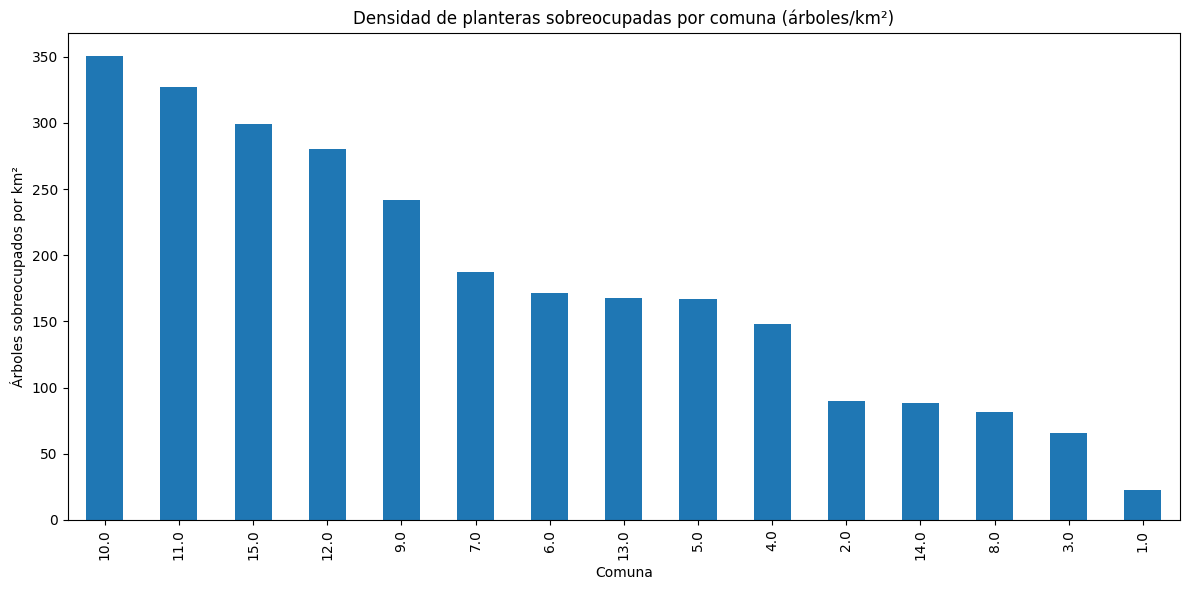

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0) Configuración y supuestos
# =========================================
# Reemplaza los valores con las superficies oficiales en km².
# Asegúrate de que las claves (1..15) coincidan con la codificación de tu columna 'comuna'.
diccionario_superficies = {
    1: 17.4,  2: 6.1,  3: 6.3,  4: 12.4,  5: 6.7,
    6: 6.8,   7: 12.4, 8: 21.9, 9: 16.6, 10: 12.7,
    11: 14.1, 12: 15.6, 13: 14.6, 14: 19.1, 15: 11.3
}

# Si tus columnas tienen otros nombres, ajusta aquí:
COL_COMUNA = "comuna"
COL_ESTADO = "estado_plantera"   # 3 = sobreocupada (según tu codificación)
COL_ESPECIE = "nombre_cientifico"

# =========================================
# 1) Validaciones rápidas
# =========================================
# Asegura que 'comuna' sea numérica para mapear bien el diccionario.
datos_arbolado = datos_arbolado.copy()
datos_arbolado[COL_COMUNA] = pd.to_numeric(datos_arbolado[COL_COMUNA], errors="coerce")

# Chequeo de claves faltantes en el diccionario de superficies
comunas_presentes = set(datos_arbolado[COL_COMUNA].dropna().unique().astype(int))
faltantes = comunas_presentes.difference(diccionario_superficies.keys())
if faltantes:
    print(f"[ADVERTENCIA] Faltan superficies para estas comunas: {sorted(faltantes)}")
    # Si faltan, no cortamos la ejecución: esas comunas quedarán con NaN en superficie

# =========================================
# 2) Conteos por comuna
# =========================================
conteo_total = datos_arbolado[COL_COMUNA].value_counts().sort_index()
conteo_sobre = (
    datos_arbolado.loc[datos_arbolado[COL_ESTADO] == 3, COL_COMUNA]
    .value_counts()
    .sort_index()
)

# DataFrame base por comuna
df_comunas = pd.DataFrame({
    "total_arboles": conteo_total,
    "sobreocupadas": conteo_sobre
}).fillna(0)

# Mapear superficies
df_comunas["superficie_km2"] = df_comunas.index.map(diccionario_superficies)

# =========================================
# 3) Métricas de densidad y enriquecimiento
# =========================================
# Densidades: árboles por km²
df_comunas["densidad_total_arboles"] = df_comunas["total_arboles"] / df_comunas["superficie_km2"]
df_comunas["densidad_sobreocupadas"] = df_comunas["sobreocupadas"] / df_comunas["superficie_km2"]

# Resumen de especies por comuna (opcional pero útil)
df_resumen = (
    datos_arbolado.groupby(COL_COMUNA)
    .agg(
        cantidad_especies=(COL_ESPECIE, "nunique"),
        cantidad_arboles=(COL_ESPECIE, "count")
    )
)
df_comunas = df_comunas.join(df_resumen, how="left")

# Orden estándar por índice de comuna
df_comunas.index.name = "comuna"
df_comunas = df_comunas.sort_index()

# =========================================
# 4) Tablas ordenadas para inspección
# =========================================
df_orden_total = df_comunas.sort_values("densidad_total_arboles", ascending=False)
df_orden_sobre = df_comunas.sort_values("densidad_sobreocupadas", ascending=False)

print("\n--- Densidad TOTAL de árboles por comuna (árboles/km²) ---")
print(df_orden_total[["densidad_total_arboles", "total_arboles", "superficie_km2", "cantidad_especies"]])

print("\n--- Densidad de PLANTERAS SOBREOCUPADAS por comuna (árboles/km²) ---")
print(df_orden_sobre[["densidad_sobreocupadas", "sobreocupadas", "superficie_km2", "cantidad_especies"]])

# =========================================
# 5) Gráficos (matplotlib, una métrica por figura)
# =========================================

# A) Densidad total de árboles
plt.figure(figsize=(12, 6))
df_orden_total["densidad_total_arboles"].plot(kind="bar")
plt.title("Densidad total de árboles por comuna (árboles/km²)")
plt.xlabel("Comuna")
plt.ylabel("Árboles por km²")
plt.tight_layout()
plt.show()

# B) Densidad de sobreocupación
plt.figure(figsize=(12, 6))
df_orden_sobre["densidad_sobreocupadas"].plot(kind="bar")
plt.title("Densidad de planteras sobreocupadas por comuna (árboles/km²)")
plt.xlabel("Comuna")
plt.ylabel("Árboles sobreocupados por km²")
plt.tight_layout()
plt.show()

# =========================================
# 6) (Opcional) Chequeos de calidad
# =========================================
# Comunas con superficie faltante (NaN) -> sus densidades serán NaN.
comunas_superficie_nan = df_comunas.index[df_comunas["superficie_km2"].isna()].tolist()
if comunas_superficie_nan:
    print(f"\n[AVISO] Hay comunas sin superficie (NaN): {comunas_superficie_nan}. "
          "Completa el diccionario para obtener densidades correctas.")

# (Opcional) Normalización por 1.000 árboles si querés tasas por mil para comunicar
# df_comunas["tasa_sobreocupadas_por_mil"] = 1_000 * df_comunas["sobreocupadas"] / df_comunas["total_arboles"]


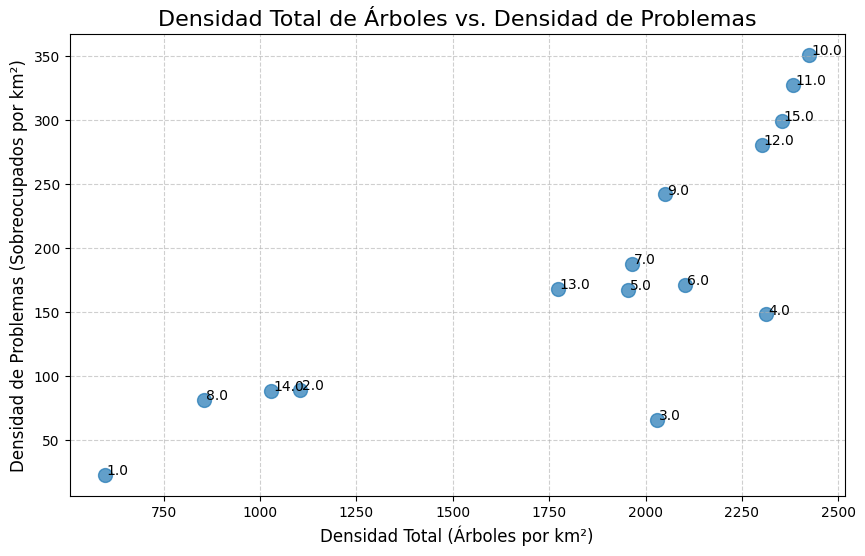

In [ ]:
# --- 1. Graficar Densidad Total vs. Densidad de Problema ---
plt.figure(figsize=(10, 6))
plt.scatter(
    df_comunas['densidad_total_arboles'],
    df_comunas['densidad_sobreocupadas'],
    alpha=0.7,
    s=100 # Puntos más grandes
)

plt.title('Densidad Total de Árboles vs. Densidad de Problemas', fontsize=16)
plt.xlabel('Densidad Total (Árboles por km²)', fontsize=12)
plt.ylabel('Densidad de Problemas (Sobreocupados por km²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# (Opcional) Añadir etiquetas a los puntos
for i, row in df_comunas.iterrows():
    plt.text(row['densidad_total_arboles'] + 5, row['densidad_sobreocupadas'], str(i))

plt.show()

In [ ]:
import numpy as np
from scipy import stats

datos_columna1= df_comunas['densidad_total_arboles']
datos_columna2= df_comunas['densidad_sobreocupadas']

# calcular la correlación de Pearson usando NumPy
#coeficiente_correlacion = np.corrcoef(datos_columna1, datos_columna2)[0, 1]
#print(coeficiente_correlacion)

# alternativamente, se puede usar SciPy:
coeficiente_correlacion, _ = stats.pearsonr(datos_columna1, datos_columna2)
print(f"Correlación entre densidad total arboles y densidad arboles con plantera sobreocupada: {coeficiente_correlacion:.4f}")


Correlación entre densidad total arboles y densidad arboles con plantera sobreocupada: 0.7997


# Hipotesis 2

In [ ]:
datos_arbolado= pd.read_pickle("../data/datos_arbolado")

datos_arbolado.head()

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,Esmeralda,1000.0,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,Pellegrini Carlos,1300.0,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,Arroyo,800.0,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,Arroyo,900.0,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,Arroyo,900.0,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


#### Vamos a analizar la proporcion de planteras sobreocupadas en el top 5 de especies.

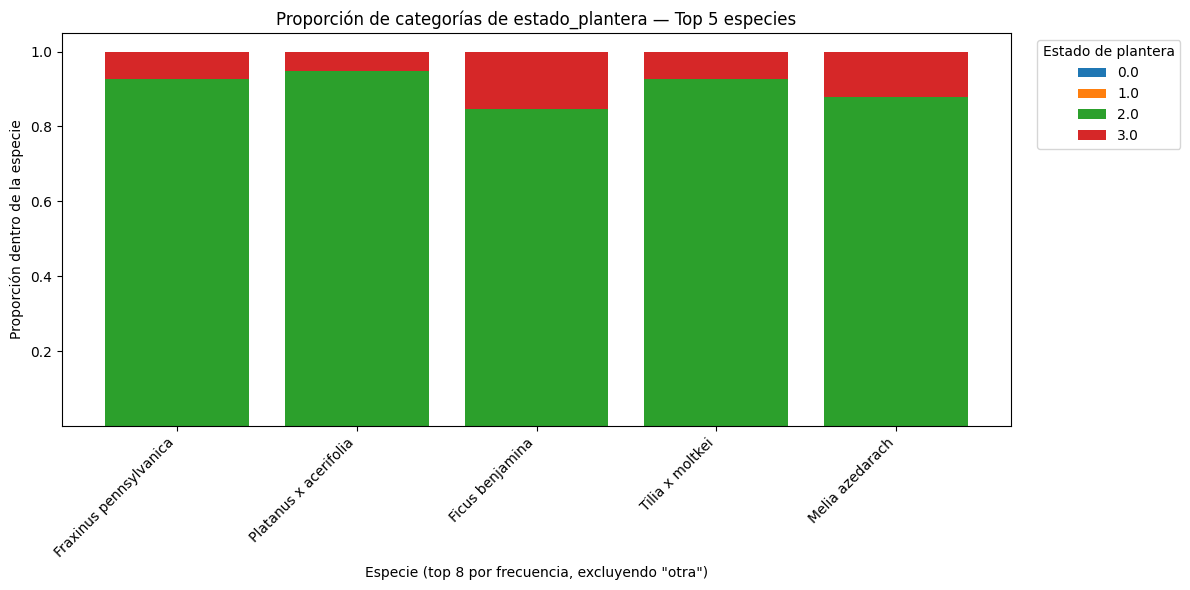

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) Excluir la especie "otra" ----
df = datos_arbolado[datos_arbolado['nombre_cientifico'] != "Otra"].copy()

# ---- 2) Seleccionar top 8 especies por frecuencia ----
top8 = df['nombre_cientifico'].value_counts().nlargest(5).index.tolist()

# Filtrar el DataFrame a esas especies
df_top8 = df[df['nombre_cientifico'].isin(top8)].copy()

# ---- 3) Calcular counts y proporciones ----
prop = (
    df_top8
    .groupby(['nombre_cientifico', 'estado_plantera'])
    .size()
    .reset_index(name='n')
)
prop['proporcion'] = prop.groupby('nombre_cientifico')['n'].transform(lambda x: x / x.sum())

# ---- 4) Pivot para formato ancho ----
pivot = prop.pivot(index='nombre_cientifico', columns='estado_plantera', values='proporcion').fillna(0)

# Asegurar orden por frecuencia
pivot = pivot.reindex(top8)

# ---- 5) Gráfico de barras apiladas ----
plt.figure(figsize=(12, 6))

bottom = pd.Series([0]*len(pivot), index=pivot.index)
for estado in pivot.columns:
    plt.bar(pivot.index, pivot[estado], bottom=bottom, label=estado)
    bottom = bottom + pivot[estado]

plt.xticks(rotation=45, ha='right')
plt.ylabel('Proporción dentro de la especie')
plt.xlabel('Especie (top 8 por frecuencia, excluyendo "otra")')
plt.title('Proporción de categorías de estado_plantera — Top 5 especies')
plt.legend(title='Estado de plantera', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


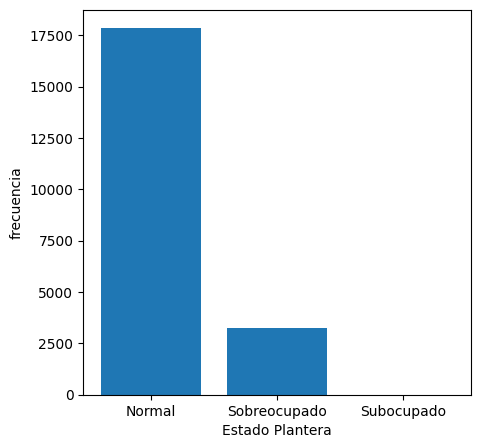

In [ ]:
datos_ficus=datos_arbolado[datos_arbolado['nombre_cientifico']=='Ficus benjamina']

estado= datos_ficus['estado_plantera'].value_counts()

mapa_labels = {
    0: 'Vacío',
    1: 'Subocupado',
    2: 'Normal',
    3: 'Sobreocupado'
}

estado = estado.rename(mapa_labels)

plt.figure(figsize=(5,5))
plt.bar(estado.index,estado.values)
plt.xlabel('Estado Plantera')
plt.ylabel('frecuencia')
plt.show()

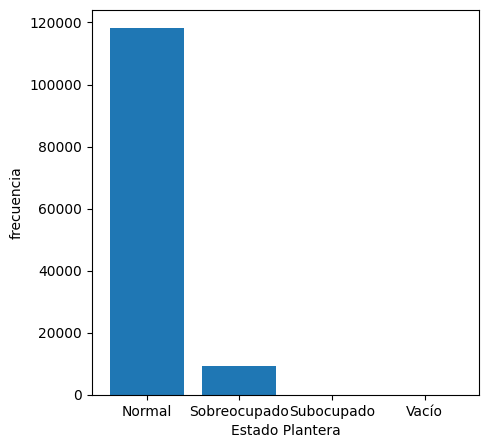

In [ ]:
datos_ficus=datos_arbolado[datos_arbolado['nombre_cientifico']=='Fraxinus pennsylvanica']

estado= datos_ficus['estado_plantera'].value_counts()

mapa_labels = {
    0: 'Vacío',
    1: 'Subocupado',
    2: 'Normal',
    3: 'Sobreocupado'
}

estado = estado.rename(mapa_labels)

plt.figure(figsize=(5,5))
plt.bar(estado.index,estado.values)
plt.xlabel('Estado Plantera')
plt.ylabel('frecuencia')
plt.show()

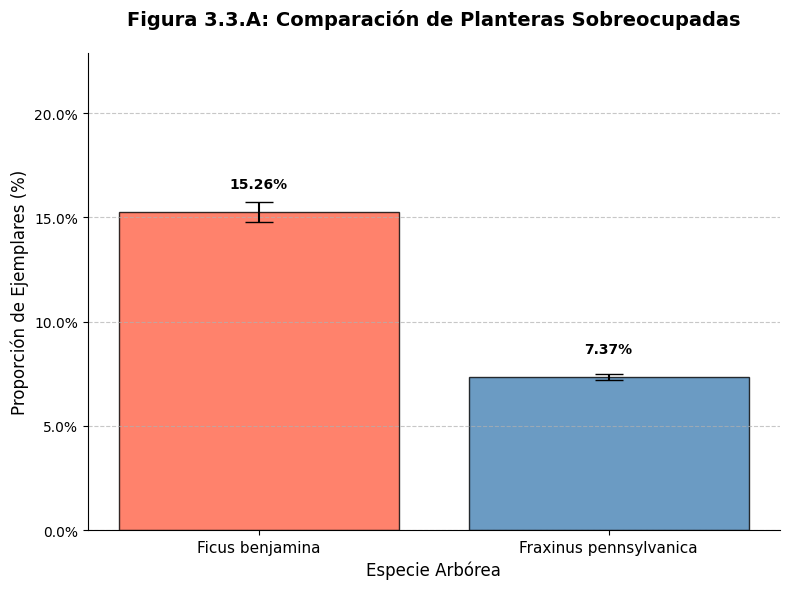

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

# --- 1. Datos de la Hipótesis ---
# Grupo 1: Ficus benjamina
x_ficus = 3263
n_ficus = 21379

# Grupo 2: Fraxinus pennsylvanica
x_fraxinus = 9431
n_fraxinus = 127973

# --- 2. Cálculos Estadísticos ---
# Calcular proporciones
p_ficus = x_ficus / n_ficus
p_fraxinus = x_fraxinus / n_fraxinus

# Calcular el Margen de Error (ME) para 95% CI
# ME = z * sqrt(p*(1-p)/n)
z = 1.96  # z-score para 95% CI

se_ficus = np.sqrt(p_ficus * (1 - p_ficus) / n_ficus)
me_ficus = z * se_ficus

se_fraxinus = np.sqrt(p_fraxinus * (1 - p_fraxinus) / n_fraxinus)
me_fraxinus = z * se_fraxinus

# Preparar datos para el gráfico
especies = ['Ficus benjamina', 'Fraxinus pennsylvanica']
proporciones = [p_ficus, p_fraxinus]
errores = [me_ficus, me_fraxinus]

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(8, 6))

# Crear las barras
bars = plt.bar(especies, proporciones, 
               yerr=errores, 
               capsize=10,  # Añade "bigotes" a las barras de error
               color=['#FF6347', '#4682B4'],  # Rojo (Ficus), Azul (Fraxinus)
               alpha=0.8,
               edgecolor='black')

# --- 4. Formato y Etiquetas ---
# Formatear el eje Y como porcentaje
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Ajustar límites del eje Y para mejor visualización
plt.ylim(0, max(proporciones) * 1.5)

# Añadir etiquetas de texto (porcentaje) sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, 
             yval + 0.01,  # Posición vertical (un poco encima de la barra)
             f'{yval:.2%}', 
             ha='center', 
             va='bottom',
             fontweight='bold')

# Títulos y etiquetas de ejes
plt.title('Figura 3.3.A: Comparación de Planteras Sobreocupadas', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Proporción de Ejemplares (%)', fontsize=12)
plt.xlabel('Especie Arbórea', fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

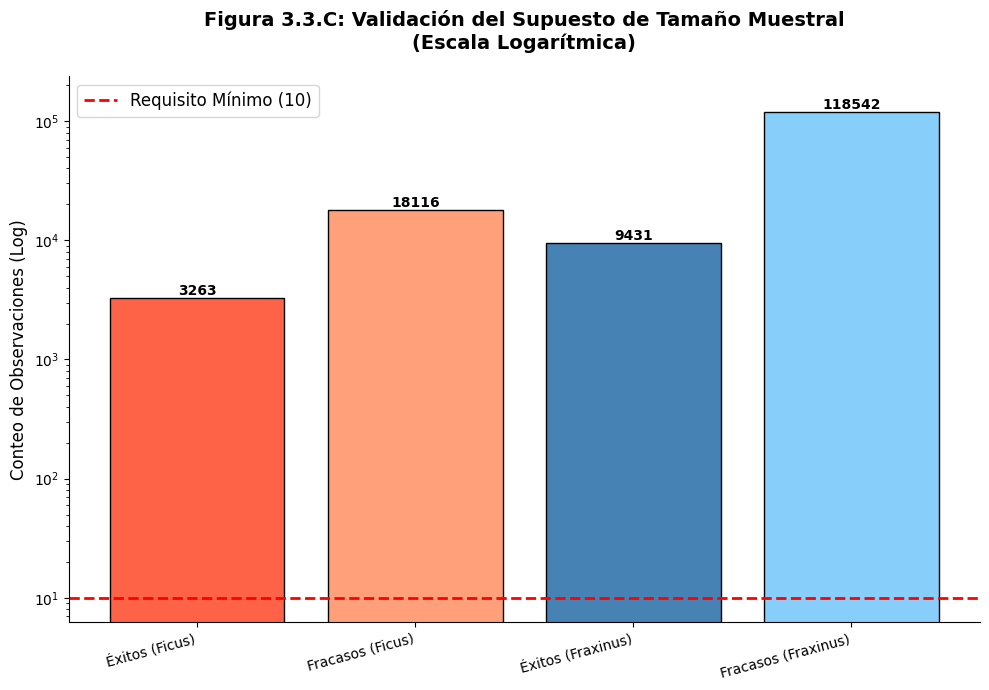

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Datos de los conteos (Éxitos/Fracasos) ---
# Grupo 1: Ficus
x_ficus = 3263
n_ficus = 21379
f_ficus = n_ficus - x_ficus # Fracasos Ficus

# Grupo 2: Fraxinus
x_fraxinus = 9431
n_fraxinus = 127973
f_fraxinus = n_fraxinus - x_fraxinus # Fracasos Fraxinus

# Requisito mínimo
requisito = 10

# --- 2. Preparar datos para el gráfico ---
etiquetas = [
    'Éxitos (Ficus)', 
    'Fracasos (Ficus)', 
    'Éxitos (Fraxinus)', 
    'Fracasos (Fraxinus)'
]
valores = [x_ficus, f_ficus, x_fraxinus, f_fraxinus]
colores = ['#FF6347', '#FFA07A', '#4682B4', '#87CEFA']

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(10, 7))

# Crear las barras
bars = plt.bar(etiquetas, valores, color=colores, edgecolor='black')

# !! --- USAR ESCALA LOGARÍTMICA --- !!
# Esto es esencial para poder ver la línea de 10
plt.yscale('log')

# Añadir la línea del requisito
plt.axhline(y=requisito, color='red', linestyle='--', linewidth=2, 
            label=f'Requisito Mínimo ({requisito})')

# --- 4. Formato y Etiquetas ---
# Añadir etiquetas de texto (conteo) sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, 
             yval, 
             f'{int(yval)}',  # Mostrar el conteo exacto
             ha='center', 
             va='bottom',
             fontsize=10,
             fontweight='bold')

# Títulos y etiquetas
plt.title('Figura 3.3.C: Validación del Supuesto de Tamaño Muestral\n(Escala Logarítmica)', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Conteo de Observaciones (Log)', fontsize=12)
plt.xticks(rotation=15, ha='right', fontsize=10) # Rotar etiquetas para que no se solapen

# Ajustar el límite Y para dar espacio
plt.ylim(top=max(valores) * 2) # Doble de altura en log
plt.legend(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Test z

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# --- 1. Datos de Entrada (Conteo de Éxitos y Totales) ---

# Grupo 1: Ficus benjamina
x_ficus = 3263
n_ficus = 21379

# Grupo 2: Fraxinus pennsylvanica
x_fraxinus = 9431
n_fraxinus = 127973

# Preparar los arrays para la función
count = np.array([x_ficus, x_fraxinus])
nobs = np.array([n_ficus, n_fraxinus])

# --- 2. Ejecución del Test ---
# H0: p1 <= p2
# HA: p1 > p2  (Por eso usamos alternative='larger')
# value=0 indica que la H0 testea que la diferencia (p1-p2) es 0.

z_stat, p_value = proportions_ztest(count, nobs, 
                                      value=0, 
                                      alternative='larger')

# --- 3. Presentación de Resultados ---
print("--- Resultados del Test Z de Dos Proporciones ---")
print(f"Hipótesis Alternativa (HA): p_ficus > p_fraxinus")
print("-" * 50)
print(f"Proporción Muestral Ficus (p1): {x_ficus/n_ficus:.4f}")
print(f"Proporción Muestral Fraxinus (p2): {x_fraxinus/n_fraxinus:.4f}")
print("-" * 50)
print(f"Estadístico Z (Z-score): {z_stat:.4f}")
print(f"P-value (unilateral): {p_value}")

--- Resultados del Test Z de Dos Proporciones ---
Hipótesis Alternativa (HA): p_ficus > p_fraxinus
--------------------------------------------------
Proporción Muestral Ficus (p1): 0.1526
Proporción Muestral Fraxinus (p2): 0.0737
--------------------------------------------------
Estadístico Z (Z-score): 38.3081
P-value (unilateral): 0.0


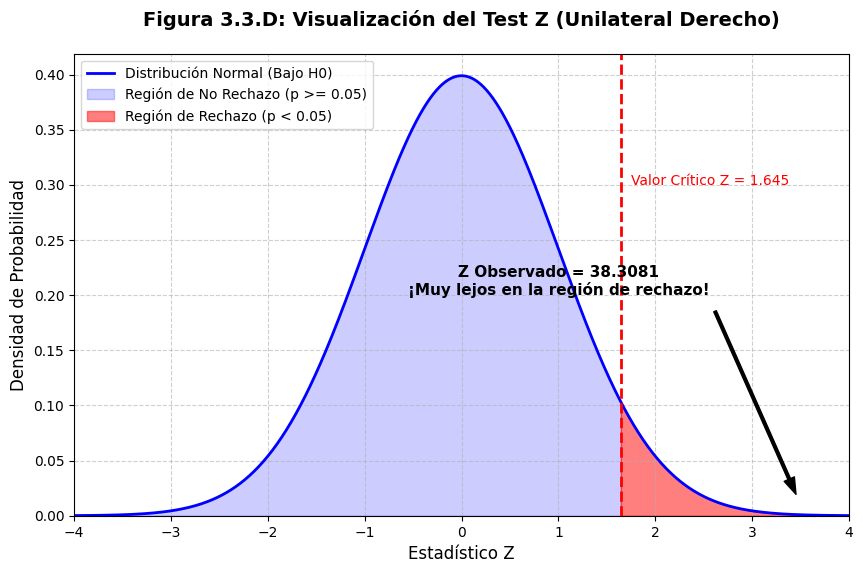

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Definir los parámetros ---
alpha = 0.05
z_critico = norm.ppf(1 - alpha)  # -> 1.645
z_observado = 38.3081

# --- 2. Crear la Curva Normal Estándar ---
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Distribución Normal (Bajo H0)')

# --- 3. Sombrear la Región de No Rechazo ---
x_no_rechazo = np.linspace(-4, z_critico, 1000)
y_no_rechazo = norm.pdf(x_no_rechazo, 0, 1)
plt.fill_between(x_no_rechazo, 0, y_no_rechazo, color='blue', alpha=0.2, 
                 label=f'Región de No Rechazo (p >= {alpha})')

# --- 4. Sombrear la Región de Rechazo ---
x_rechazo = np.linspace(z_critico, 4, 1000)
y_rechazo = norm.pdf(x_rechazo, 0, 1)
plt.fill_between(x_rechazo, 0, y_rechazo, color='red', alpha=0.5, 
                 label=f'Región de Rechazo (p < {alpha})')

# --- 5. Anotar los puntos clave ---

# Valor Crítico
plt.axvline(z_critico, color='red', linestyle='--', linewidth=2)
plt.text(z_critico + 0.1, 0.3, f'Valor Crítico Z = {z_critico:.3f}', 
         color='red', ha='left')

# Estadístico Z Observado (Anotación)
# Dado que 38.31 está fuera del gráfico, usamos una flecha
plt.annotate(
    f'Z Observado = {z_observado}\n¡Muy lejos en la región de rechazo!',
    xy=(3.5, 0.01),  # Dónde apunta la flecha (extremo del gráfico)
    xytext=(1, 0.2),  # Dónde está el texto
    fontsize=11,
    fontweight='bold',
    arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
    ha='center'
)

# --- 6. Formato del Gráfico ---
plt.title('Figura 3.3.D: Visualización del Test Z (Unilateral Derecho)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Estadístico Z', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc='upper left')
plt.grid(linestyle='--', alpha=0.6)
plt.ylim(bottom=0)
plt.xlim(-4, 4) # Forzamos la vista estándar

plt.show()

# Hipotesis 3

In [ ]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [ ]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335516 entries, 0 to 370055
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   335516 non-null  float64
 1   lat                    335516 non-null  float64
 2   comuna                 335516 non-null  float64
 3   calle_nombre           335516 non-null  object 
 4   calle_altura           335516 non-null  float64
 5   calle_chapa            332263 non-null  Int32  
 6   nombre_cientifico      335516 non-null  object 
 7   ancho_acera            335516 non-null  float64
 8   estado_plantera        335367 non-null  float64
 9   ubicacion_plantera     334690 non-null  object 
 10  nivel_plantera         334874 non-null  float64
 11  diametro_altura_pecho  335516 non-null  float64
 12  altura_arbol           335516 non-null  float64
dtypes: Int32(1), float64(9), object(3)
memory usage: 34.9+ MB


In [ ]:
datos_limpios=datos_limpios[datos_limpios['altura_arbol'].notna()]
datos_limpios= datos_limpios[datos_limpios['nivel_plantera'].notna()]
datos_limpios= datos_limpios[datos_limpios['estado_plantera'].notna()]

In [ ]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334726 entries, 0 to 370055
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   334726 non-null  float64
 1   lat                    334726 non-null  float64
 2   comuna                 334726 non-null  float64
 3   calle_nombre           334726 non-null  object 
 4   calle_altura           334726 non-null  float64
 5   calle_chapa            331491 non-null  Int32  
 6   nombre_cientifico      334726 non-null  object 
 7   ancho_acera            334726 non-null  float64
 8   estado_plantera        334726 non-null  float64
 9   ubicacion_plantera     334058 non-null  object 
 10  nivel_plantera         334726 non-null  float64
 11  diametro_altura_pecho  334726 non-null  float64
 12  altura_arbol           334726 non-null  float64
dtypes: Int32(1), float64(9), object(3)
memory usage: 34.8+ MB


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer # Para rellenar nulos

# 1. Seleccionar features y limpiar nulos
features_quant = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']
df_quant = datos_limpios[features_quant].copy()

# Rellenamos los nulos de altura (el clustering no acepta nulos)
imputer = SimpleImputer(strategy='median')
df_quant_imputed = imputer.fit_transform(df_quant)

# 2. Estandarizar los datos (¡EL PASO MÁS IMPORTANTE!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_quant_imputed)

# 3. Correr K-Means (ej. buscando 4 "tipos" de árboles)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# 4. Asignar los "tipos" de árbol de vuelta al DataFrame
datos_limpios['cluster_fenotipo'] = kmeans.labels_

# 5. Entender los clústeres
# (Invierte la escala para ver los centros en metros y cm)
centros = scaler.inverse_transform(kmeans.cluster_centers_)
df_centros = pd.DataFrame(centros, columns=features_quant)
print("Centros de los Clústeres (en unidades originales):")
print(df_centros)


Centros de los Clústeres (en unidades originales):
   ancho_acera  diametro_altura_pecho  altura_arbol
0     4.041667              65.082763     16.177554
1     4.674249              32.428833      8.426874
2     3.415684              11.857425      4.198366
3     2.883203              32.805500      9.999511


In [ ]:
grupo=datos_limpios[datos_limpios['cluster_fenotipo']==3]
grupo['nombre_cientifico'].value_counts()

nombre_cientifico
Fraxinus pennsylvanica                 58821
Otra                                    6656
Ficus benjamina                         5839
Tilia x moltkei                         4428
Fraxinus americana                      3969
Fraxinus excelsior                      3919
Melia azedarach                         3057
Jacaranda mimosifolia                   2912
Platanus x acerifolia                   2156
Acer negundo                            1935
Ligustrum lucidum                       1849
Ligustrum lucidum f. aureovariegata     1439
Liquidambar styraciflua                 1109
Syagrus romanzoffiana                    898
Styphnolobium japonicum                  724
Tilia cordata                            593
Lagerstroemia indica                     587
Tipuana tipu                             561
Robinia pseudoacacia                     450
Persea americana                         339
Name: count, dtype: int64

Analisis por especies en los cluster

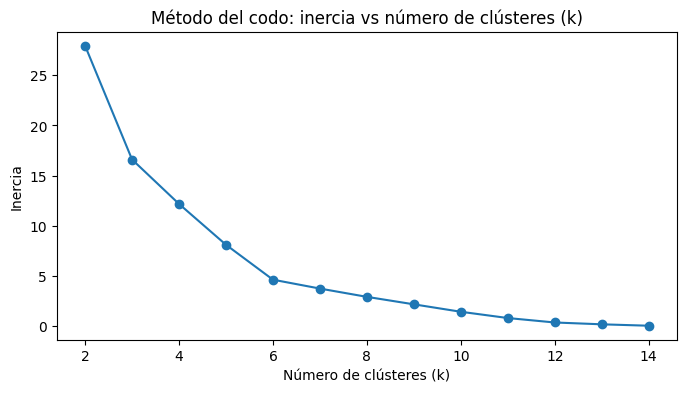

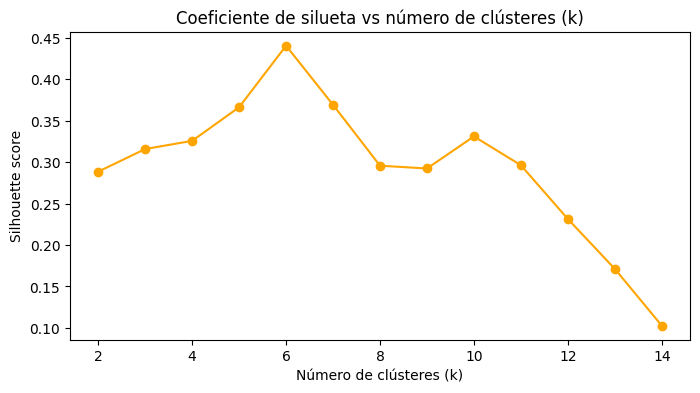

Centros de los clústeres de comunas (en unidades originales):
   ancho_acera  diametro_altura_pecho  altura_arbol  cluster_comuna
0     3.364827              31.627381      9.682623               0
1     3.967635              31.516775      7.462097               1
2     3.596134              35.329717     11.287756               2
3     3.041939              25.963088      9.778076               3
4     3.619878              27.643475      8.395278               4
5     3.899680              35.062937      9.306831               5

Silhouette score: 0.4403089337668464
Davies-Bouldin index: 0.6220095156905564

Asignación de clúster a datos_limpios completada:
   comuna  cluster_comuna
0     1.0               4
1     1.0               4
2     1.0               4
3     1.0               4
4     1.0               4


/tmp/ipykernel_110254/2764280826.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_110254/2764280826.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


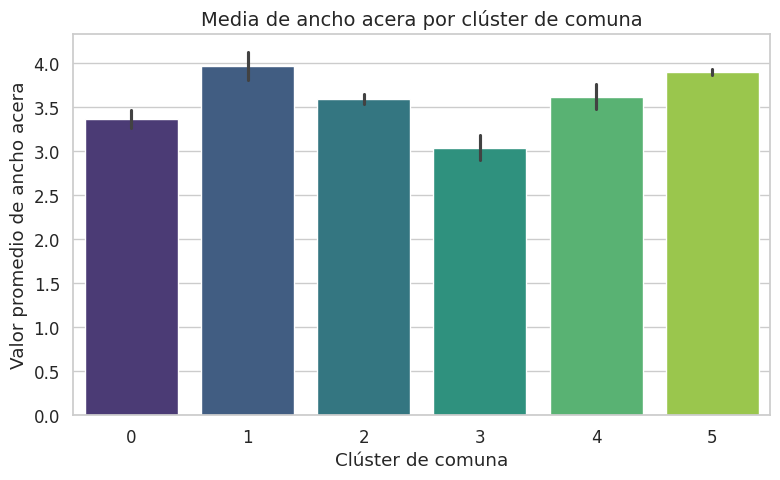

/tmp/ipykernel_110254/2764280826.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_110254/2764280826.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


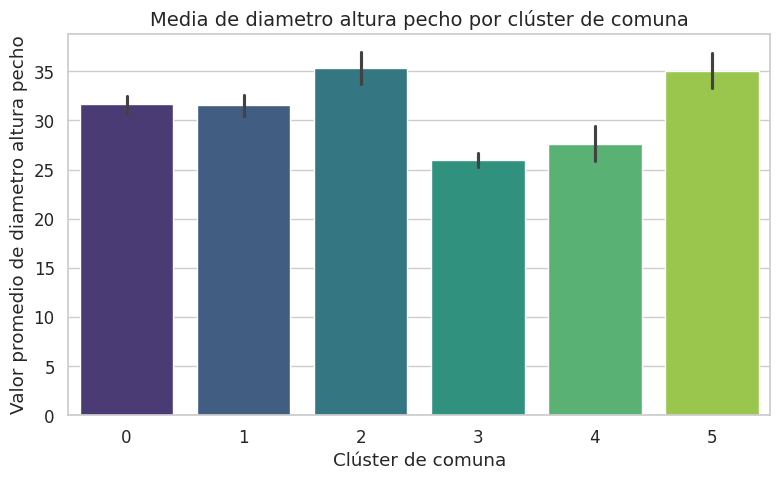

/tmp/ipykernel_110254/2764280826.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_110254/2764280826.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


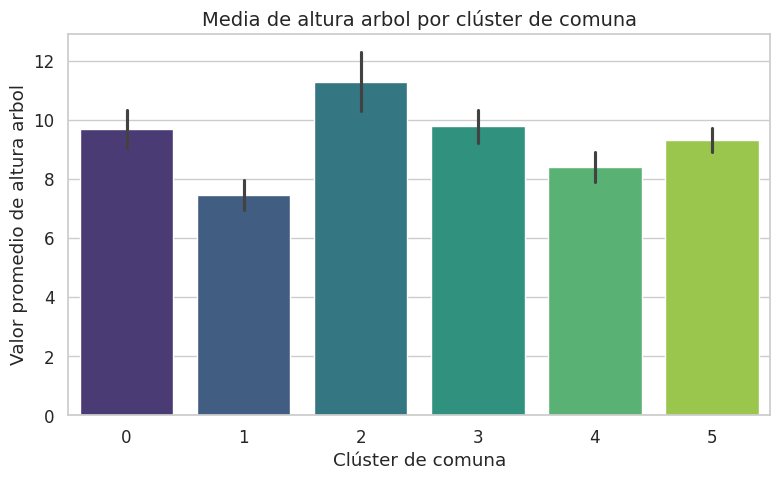

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3.1 Agrupación por comuna ---
df = datos_limpios.copy()

# Asegurá que no haya nulos en las variables necesarias
df = df.dropna(subset=['comuna', 'ancho_acera', 'diametro_altura_pecho', 'altura_arbol'])

# Calcular medias por comuna
grouped = df.groupby('comuna')[['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']].mean().reset_index()

# --- 3.2 Estandarización ---
scaler = StandardScaler()
X = scaler.fit_transform(grouped[['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']])

# --- 3.3 Evaluación de número óptimo de clusters ---
inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Gráficos de evaluación
plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, marker='o')
plt.title('Método del codo: inercia vs número de clústeres (k)')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Coeficiente de silueta vs número de clústeres (k)')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Silhouette score')
plt.show()

# --- 3.4 Ejecución final del clustering ---
k_opt = 6  # ajustar según resultados del método del codo o silueta
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
grouped['cluster_comuna'] = km_final.fit_predict(X)

# --- 3.5 Inversión de la escala para interpretar centros ---
centers = scaler.inverse_transform(km_final.cluster_centers_)
df_centers = pd.DataFrame(centers, columns=['ancho_acera', 'diametro_altura_pecho', 'altura_arbol'])
df_centers['cluster_comuna'] = range(k_opt)

print("Centros de los clústeres de comunas (en unidades originales):")
print(df_centers)

# --- 3.6 Métricas de validación del modelo ---
labels_final = grouped['cluster_comuna'].values
print("\nSilhouette score:", silhouette_score(X, labels_final))
print("Davies-Bouldin index:", davies_bouldin_score(X, labels_final))

# --- 3.7 Asignar el clúster a cada registro de datos_limpios ---
# Se hace merge por comuna
df = df.merge(grouped[['comuna', 'cluster_comuna']], on='comuna', how='left')

print("\nAsignación de clúster a datos_limpios completada:")
print(df[['comuna', 'cluster_comuna']].head())

# --- 3.8 Visualización de las medias por variable y clúster ---
sns.set(style='whitegrid', palette='viridis', font_scale=1.1)
variables = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']

for var in variables:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=grouped,
        x='cluster_comuna',
        y=var,
        palette='viridis',
        ci='sd'
    )
    plt.title(f'Media de {var.replace("_", " ")} por clúster de comuna', fontsize=14)
    plt.xlabel('Clúster de comuna')
    plt.ylabel(f'Valor promedio de {var.replace("_", " ")}')
    plt.tight_layout()
    plt.show()

# --- 3.9 Confirmación final ---
# df ahora contiene los clústeres y está listo para pruebas de hipótesis
datos_limpios = df.copy()



Index(['ID', 'OBJETO', 'COMUNAS', 'BARRIOS', 'PERIMETRO', 'AREA', 'geometry'], dtype='object')
[ 2.  6. 10. 11. 12. 14. 15. 13.  4.  5.  7.  3.  9.  8.  1.]
Comunases sin cluster asignado: 0 de 15


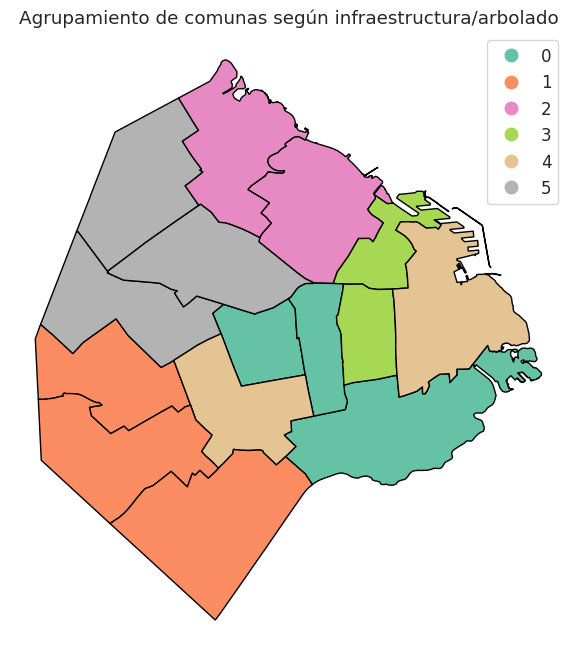

In [ ]:
import geopandas as gpd
import pandas as pd

# Cargar geojson
comunas_geo = gpd.read_file('../data/caba_comunas.geojson')

# Mostrar los nombres de columnas para confirmar
print(comunas_geo.columns)
print(comunas_geo['COMUNAS'].unique())

# Asegurar que el dataframe de comunas tenga la misma clave
grouped['comuna_num'] = grouped['comuna'].astype(float)  # si tu columna era int o string
# O si ya era float, asegurarse de formato
grouped['comuna_num'] = grouped['comuna_num'].round(0).astype(int)

# En el geo dataframe, creamos una columna de tipo int
comunas_geo['comuna_num'] = comunas_geo['COMUNAS'].round(0).astype(int)

# Realizar merge
map_df = comunas_geo.merge(grouped[['comuna_num','cluster_comuna']], on='comuna_num', how='left')

# Verificar cuántas comunas quedaron sin asignar
print("Comunases sin cluster asignado:", map_df['cluster_comuna'].isna().sum(), "de", len(map_df))

# Graficar
map_df.plot(column='cluster_comuna', categorical=True, legend=True, cmap='Set2', edgecolor='black', figsize=(8,8))
plt.title('Agrupamiento de comunas según infraestructura/arbolado')
plt.axis('off')
plt.show()


In [ ]:
from scipy.stats import kruskal

# Supongamos que tus datos individuales están en 'datos_limpios' con la variable cluster asignada
variables = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']

for var in variables:
    grupos = [datos_limpios.loc[datos_limpios['cluster_comuna'] == c, var] for c in sorted(datos_limpios['cluster_comuna'].unique())]
    stat, p = kruskal(*grupos)
    print(f'{var}: estadístico H = {stat:.3f}, p = {p:.5f}')


ancho_acera: estadístico H = 37180.418, p = 0.00000
diametro_altura_pecho: estadístico H = 5578.055, p = 0.00000
altura_arbol: estadístico H = 17818.735, p = 0.00000


In [ ]:
datos_limpios['cluster_comuna'].value_counts()

cluster_comuna
5    96038
1    83335
0    55840
2    45406
4    34633
3    19474
Name: count, dtype: int64

/tmp/ipykernel_110254/2586909809.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_h, x='Variable', y='H', palette='viridis')


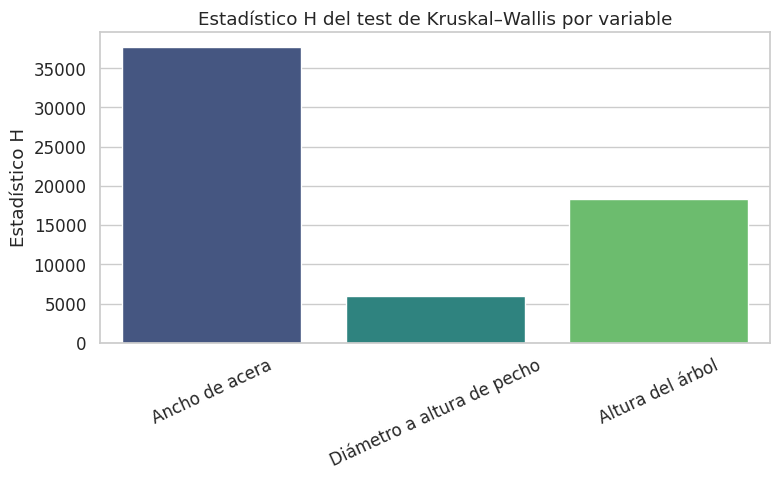

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos del test (tus resultados)
data = {
    'Variable': ['Ancho de acera', 'Diámetro a altura de pecho', 'Altura del árbol'],
    'H': [37680.690, 5897.719, 18298.395],
    'p_value': [0.00001, 0.00001, 0.00001]
}
df_h = pd.DataFrame(data)

# Graficar el estadístico H
plt.figure(figsize=(8,5))
sns.barplot(data=df_h, x='Variable', y='H', palette='viridis')
plt.title('Estadístico H del test de Kruskal–Wallis por variable')
plt.xlabel('')
plt.ylabel('Estadístico H')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# Hipotesis 4

Dimensiones del dataset: (335516, 13)

Primeras filas:
Información sobre las variables clave:
Diámetro promedio: 32.43 cm
Diámetro mediano: 29.00 cm
Número de especies únicas: 20

Especies más frecuentes:
nombre_cientifico
Fraxinus pennsylvanica    127674
Otra                       42488
Platanus x acerifolia      29570
Ficus benjamina            21087
Tilia x moltkei            14738
Melia azedarach            13882
Jacaranda mimosifolia      12396
Lagerstroemia indica       11303
Fraxinus americana          9605
Ligustrum lucidum           8558
Name: count, dtype: int64
Número de especies retenidas: 20
Número total de observaciones: 335516

Especies retenidas:
['Fraxinus pennsylvanica', 'Otra', 'Platanus x acerifolia', 'Ficus benjamina', 'Tilia x moltkei', 'Melia azedarach', 'Jacaranda mimosifolia', 'Lagerstroemia indica', 'Fraxinus americana', 'Ligustrum lucidum', 'Fraxinus excelsior', 'Ligustrum lucidum f. aureovariegata', 'Tipuana tipu', 'Liquidambar styraciflua', 'Acer negundo', 

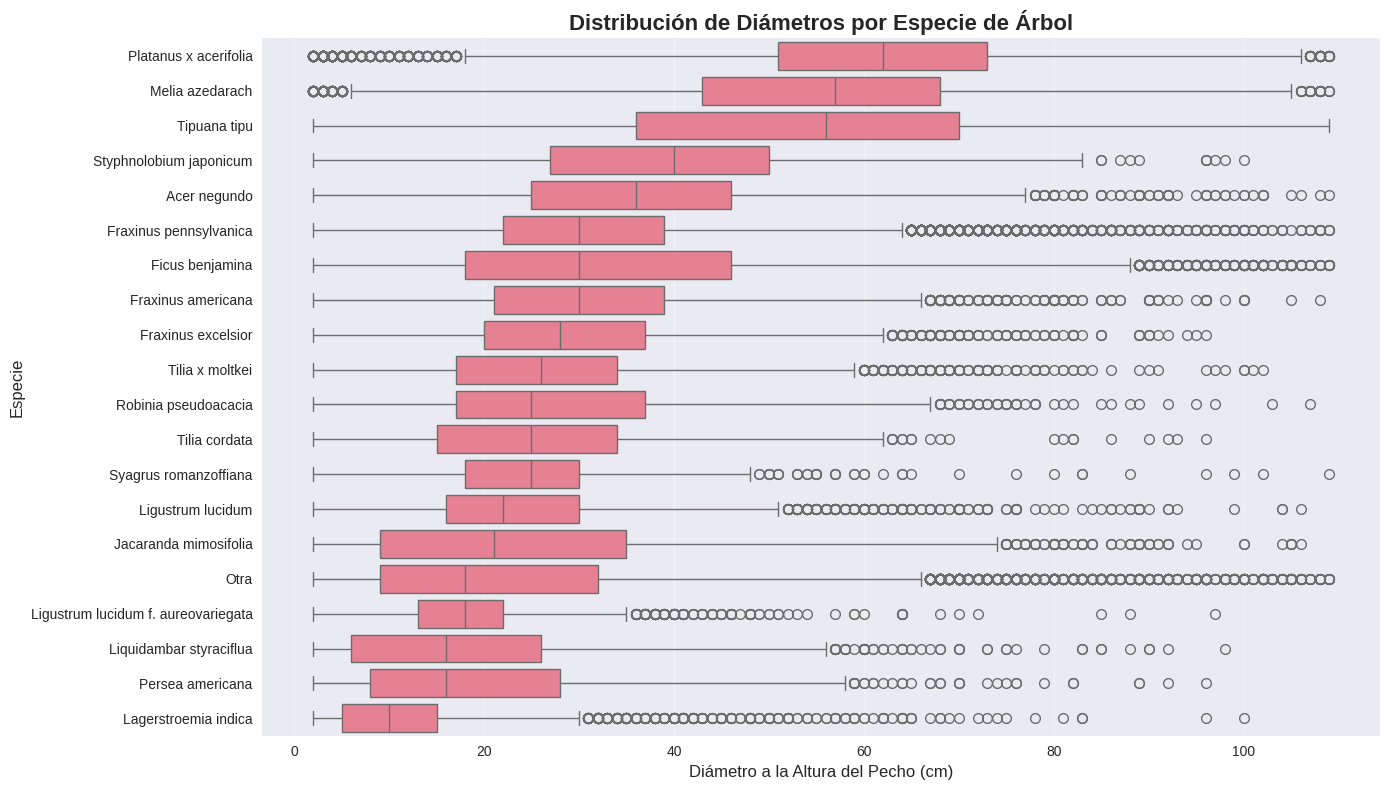

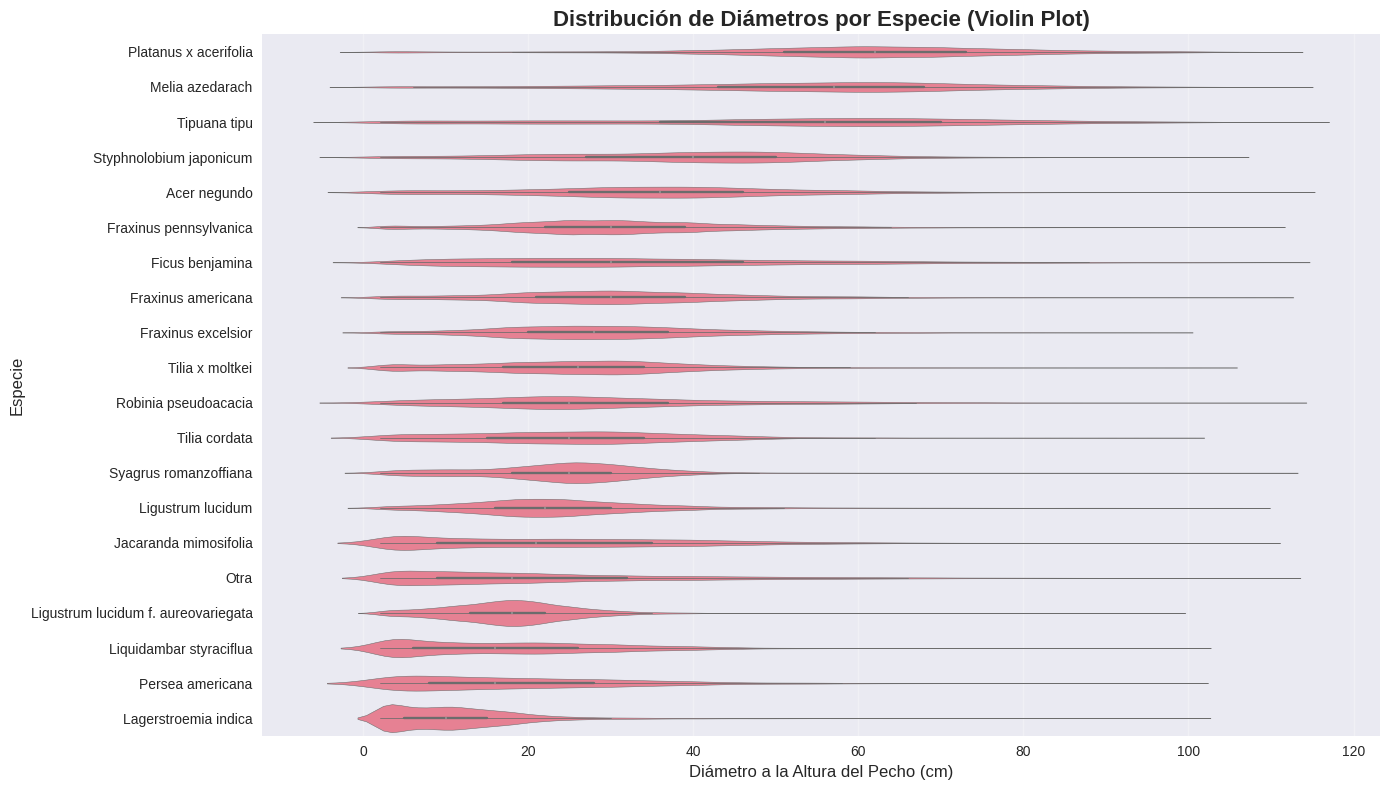

Número de grupos (especies) para la prueba: 20
Tamaños de los grupos: [127674, 42488, 29570, 21087, 14738, 13882, 12396, 11303, 9605, 8558, 8182, 7725, 7333, 5288, 4869, 3047, 2060, 2041, 1846, 1824]
PRUEBA DE KRUSKAL-WALLIS
Estadística H de Kruskal-Wallis: 104789.8138
Valor p: 0.0000000000
Valor p (notación científica): 0.00e+00

INTERPRETACIÓN:
--------------------
✓ Se rechaza la hipótesis nula (p-value < 0.05)
✓ Existen diferencias estadísticamente significativas entre los diámetros de las diferentes especies de árboles

PRUEBA DE NORMALIDAD (SHAPIRO-WILK) SOBRE LOS DIÁMETROS
Prueba de Shapiro-Wilk sobre todos los diámetros:
  Estadística: 0.9521
  Valor p: 0.0000000000
  ✓ Los datos no siguen una distribución normal
  ✓ La prueba de Kruskal-Wallis es apropiada


/home/atreus/workspace/repositorios_ingenieria/TP-Ciencia-De-Datos-Grupo14/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 335516.
  res = hypotest_fun_out(*samples, **kwds)


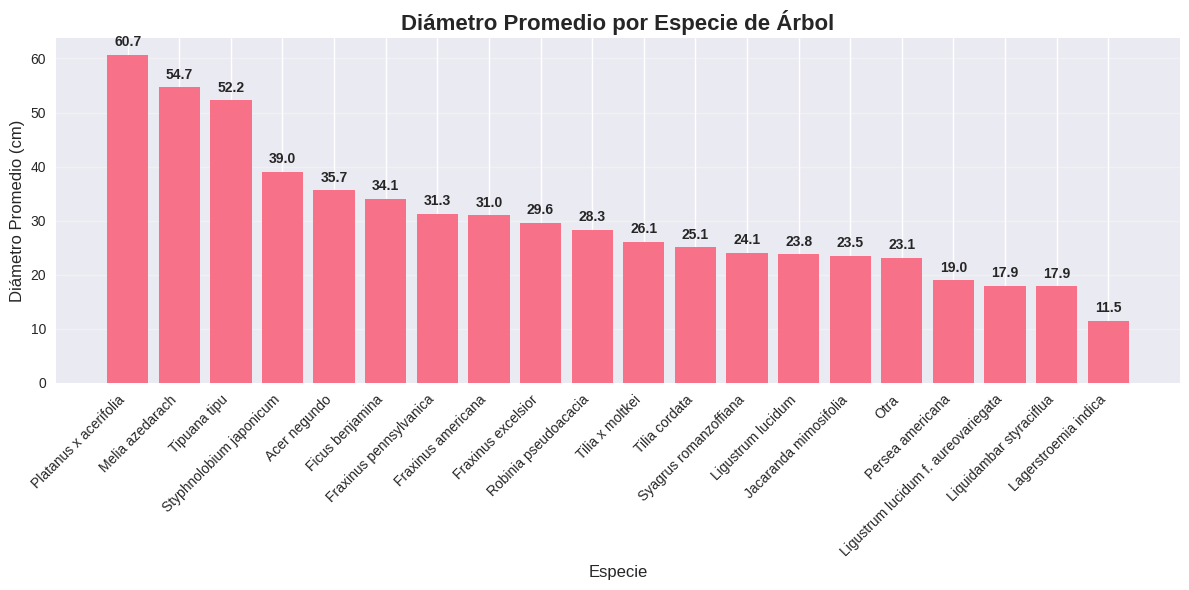

RESUMEN DE RESULTADOS
• Hipótesis probada: Los diámetros difieren según las especies de árboles
• Prueba utilizada: Kruskal-Wallis (no paramétrica)
• Número de especies comparadas: 20
• Resultado de la prueba: SIGNIFICATIVO
• P-value: 0.00e+00
• Especie con mayor diámetro promedio: Platanus x acerifolia (60.7 cm)
• Especie con menor diámetro promedio: Lagerstroemia indica (11.5 cm)

CONCLUSIÓN: Existen diferencias significativas en los diámetros según las especies.
Esto podría explicarse por diferencias en:
  - La velocidad de crecimiento de las especies
  - La edad de los árboles plantados
  - Las condiciones de crecimiento


In [1]:
# Prueba de Hipótesis 1: Comparación de diámetros entre especies de árboles
## Prueba de Kruskal-Wallis
# Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Carga de datos
df = pd.read_pickle('../data/datos_arbolado')

# Visualización de las primeras filas e información básica
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()
# Información sobre las variables de interés
print("Información sobre las variables clave:")
print(f"Diámetro promedio: {df['diametro_altura_pecho'].mean():.2f} cm")
print(f"Diámetro mediano: {df['diametro_altura_pecho'].median():.2f} cm")
print(f"Número de especies únicas: {df['nombre_cientifico'].nunique()}")

print("\nEspecies más frecuentes:")
especies_counts = df['nombre_cientifico'].value_counts()
print(especies_counts.head(10))
# Selección de especies con al menos 10 observaciones para una mejor fiabilidad estadística
especies_frecuentes = especies_counts[especies_counts >= 10].index
df_filtrado = df[df['nombre_cientifico'].isin(especies_frecuentes)]

print(f"Número de especies retenidas: {len(especies_frecuentes)}")
print(f"Número total de observaciones: {len(df_filtrado)}")
print("\nEspecies retenidas:")
print(especies_frecuentes.tolist())
# Estadísticas descriptivas por especie
print("ESTADÍSTICAS DESCRIPTIVAS POR ESPECIE")
print("=" * 50)

stats_especies = df_filtrado.groupby('nombre_cientifico')['diametro_altura_pecho'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

stats_especies_sorted = stats_especies.sort_values('mean', ascending=False)
stats_especies_sorted
# Visualización 1: Boxplot de los diámetros por especie
plt.figure(figsize=(14, 8))

# Ordenar por diámetro mediano
especies_ordenadas = df_filtrado.groupby('nombre_cientifico')['diametro_altura_pecho'].median().sort_values(ascending=False).index

sns.boxplot(data=df_filtrado, 
            x='diametro_altura_pecho', 
            y='nombre_cientifico',
            order=especies_ordenadas)

plt.title('Distribución de Diámetros por Especie de Árbol', fontsize=16, fontweight='bold')
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Especie', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
# Visualización 2: Violin plot para ver la densidad de distribución
plt.figure(figsize=(14, 8))

sns.violinplot(data=df_filtrado, 
               x='diametro_altura_pecho', 
               y='nombre_cientifico',
               order=especies_ordenadas)

plt.title('Distribución de Diámetros por Especie (Violin Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Especie', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
# Preparación de datos para la prueba de Kruskal-Wallis
grupos = []
for especie in especies_frecuentes:
    grupo = df_filtrado[df_filtrado['nombre_cientifico'] == especie]['diametro_altura_pecho']
    grupos.append(grupo)

print(f"Número de grupos (especies) para la prueba: {len(grupos)}")
print(f"Tamaños de los grupos: {[len(g) for g in grupos]}")
# Prueba de Kruskal-Wallis
print("PRUEBA DE KRUSKAL-WALLIS")
print("=" * 40)

statistic, p_value = stats.kruskal(*grupos)

print(f"Estadística H de Kruskal-Wallis: {statistic:.4f}")
print(f"Valor p: {p_value:.10f}")
print(f"Valor p (notación científica): {p_value:.2e}")

# Interpretación
alpha = 0.05
print("\nINTERPRETACIÓN:")
print("-" * 20)
if p_value < alpha:
    print(f"✓ Se rechaza la hipótesis nula (p-value < {alpha})")
    print("✓ Existen diferencias estadísticamente significativas entre los diámetros de las diferentes especies de árboles")
else:
    print(f"✗ No se puede rechazar la hipótesis nula (p-value ≥ {alpha})")
    print("✗ No hay diferencias estadísticamente significativas entre los diámetros de las diferentes especies")
# Prueba de normalidad (Shapiro-Wilk) sobre los residuos para verificar los supuestos
print("\nPRUEBA DE NORMALIDAD (SHAPIRO-WILK) SOBRE LOS DIÁMETROS")
print("=" * 55)

# Prueba sobre el conjunto de datos
stat_shapiro, p_shapiro = stats.shapiro(df_filtrado['diametro_altura_pecho'])
print(f"Prueba de Shapiro-Wilk sobre todos los diámetros:")
print(f"  Estadística: {stat_shapiro:.4f}")
print(f"  Valor p: {p_shapiro:.10f}")

if p_shapiro < 0.05:
    print("  ✓ Los datos no siguen una distribución normal")
    print("  ✓ La prueba de Kruskal-Wallis es apropiada")
else:
    print("  ✗ Los datos podrían seguir una distribución normal")
# Visualización de las diferencias con un gráfico de barras de los diámetros promedios
plt.figure(figsize=(12, 6))

diametros_medios = df_filtrado.groupby('nombre_cientifico')['diametro_altura_pecho'].mean().sort_values(ascending=False)

bars = plt.bar(range(len(diametros_medios)), diametros_medios.values)
plt.xticks(range(len(diametros_medios)), diametros_medios.index, rotation=45, ha='right')

# Adición de valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title('Diámetro Promedio por Especie de Árbol', fontsize=16, fontweight='bold')
plt.ylabel('Diámetro Promedio (cm)', fontsize=12)
plt.xlabel('Especie', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# Resumen de resultados
print("RESUMEN DE RESULTADOS")
print("=" * 30)
print(f"• Hipótesis probada: Los diámetros difieren según las especies de árboles")
print(f"• Prueba utilizada: Kruskal-Wallis (no paramétrica)")
print(f"• Número de especies comparadas: {len(especies_frecuentes)}")
print(f"• Resultado de la prueba: {'SIGNIFICATIVO' if p_value < alpha else 'NO SIGNIFICATIVO'}")
print(f"• P-value: {p_value:.2e}")
print(f"• Especie con mayor diámetro promedio: {diametros_medios.index[0]} ({diametros_medios.iloc[0]:.1f} cm)")
print(f"• Especie con menor diámetro promedio: {diametros_medios.index[-1]} ({diametros_medios.iloc[-1]:.1f} cm)")

if p_value < alpha:
    print("\nCONCLUSIÓN: Existen diferencias significativas en los diámetros según las especies.")
    print("Esto podría explicarse por diferencias en:")
    print("  - La velocidad de crecimiento de las especies")
    print("  - La edad de los árboles plantados")
    print("  - Las condiciones de crecimiento")
else:
    print("\nCONCLUSIÓN: No se detectó ninguna diferencia significativa entre las especies.")

# Hipotesis 5

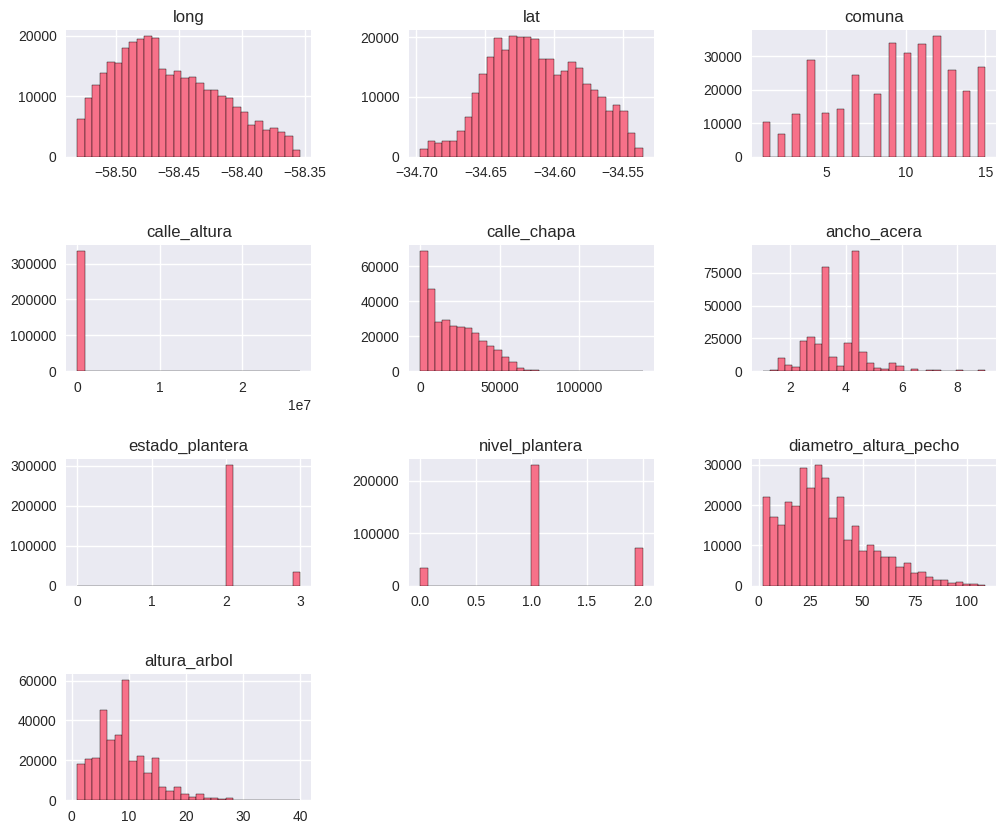

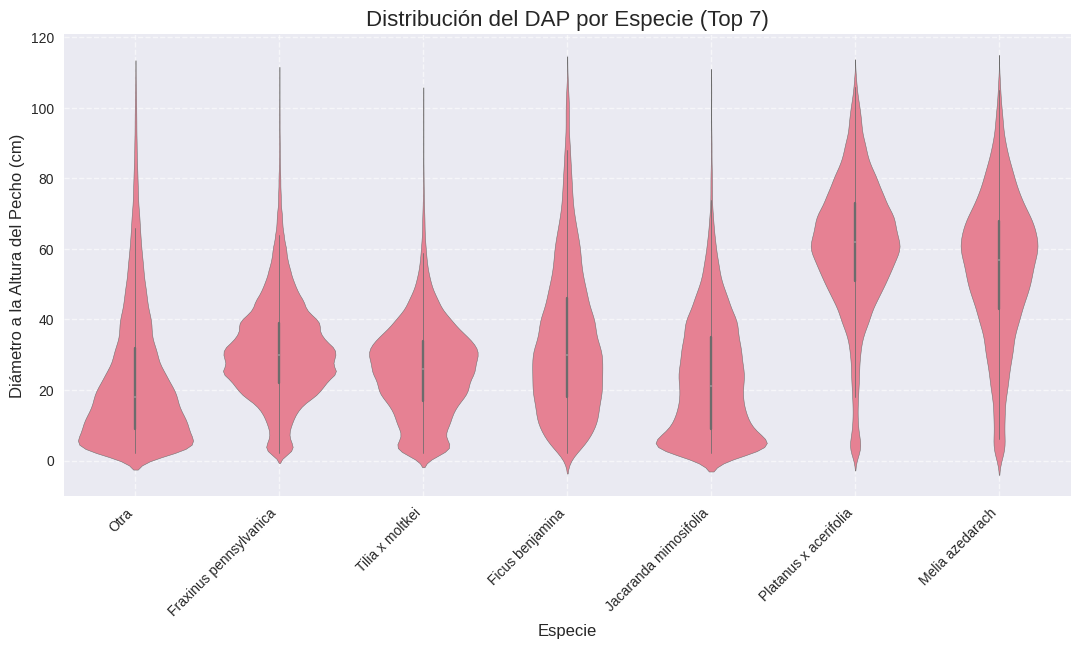

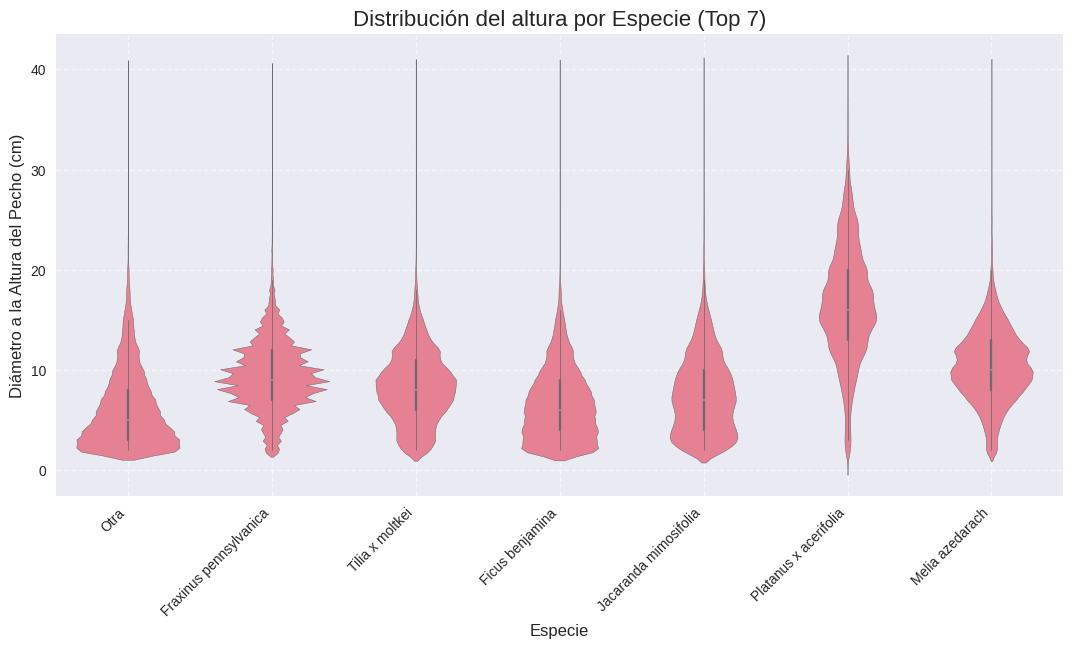

diametro_altura_pecho: estadístico H = 104789.814, p = 0.00000
altura_arbol: estadístico H = 110925.572, p = 0.00000

POSTHOC VS PLATANUS X ACERIFOLIA PARA DIAMETRO_ALTURA_PECHO
                                           p_valor  significativa
Acer negundo                          0.000000e+00           True
Ficus benjamina                       0.000000e+00           True
Fraxinus americana                    0.000000e+00           True
Fraxinus excelsior                    0.000000e+00           True
Fraxinus pennsylvanica                0.000000e+00           True
Jacaranda mimosifolia                 0.000000e+00           True
Lagerstroemia indica                  0.000000e+00           True
Ligustrum lucidum                     0.000000e+00           True
Ligustrum lucidum f. aureovariegata   0.000000e+00           True
Liquidambar styraciflua               0.000000e+00           True
Melia azedarach                       1.190687e-87           True
Otra                          

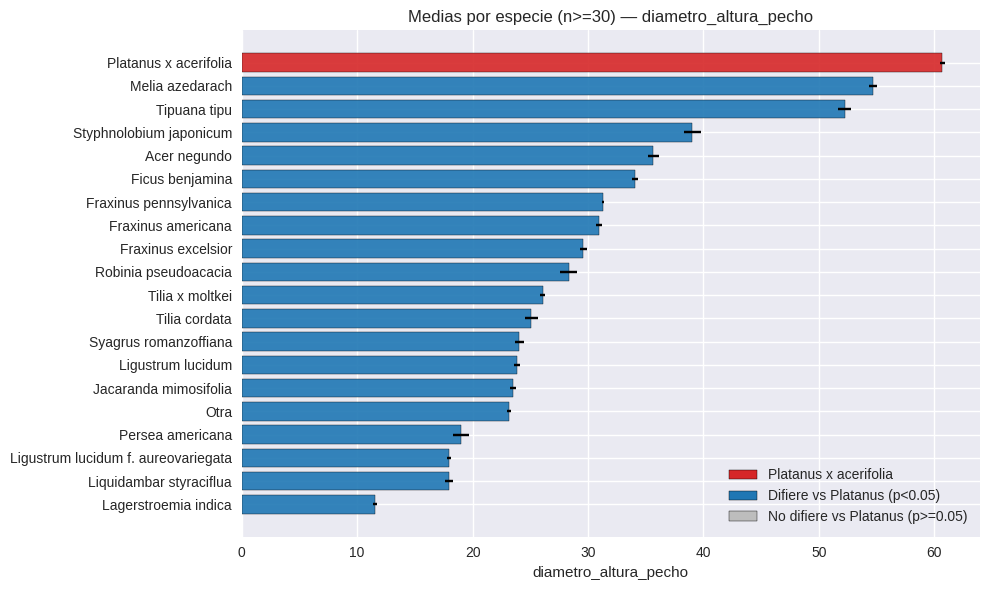


Resumen rápido: de 20 especies con n>=30, 19 difieren estadísticamente de Platanus x acerifolia (post-hoc Dunn, Holm).

VARIABLE: altura_arbol
                  nombre_cientifico      n media  ci95   p_valor significativa_vs_platanus
              Platanus x acerifolia  29570 16.61 ±0.06  1.00e+00                        No
                       Tipuana tipu   7333 14.82 ±0.15 9.14e-131                        Sí
                    Melia azedarach  13882 10.40 ±0.06  0.00e+00                        Sí
                 Fraxinus americana   9605  9.44 ±0.07  0.00e+00                        Sí
             Fraxinus pennsylvanica 127674  9.43 ±0.02  0.00e+00                        Sí
                 Fraxinus excelsior   8182  9.10 ±0.07  0.00e+00                        Sí
                       Acer negundo   4869  8.64 ±0.09  0.00e+00                        Sí
                      Tilia cordata   2041  8.46 ±0.17  0.00e+00                        Sí
                    Tilia x moltkei  

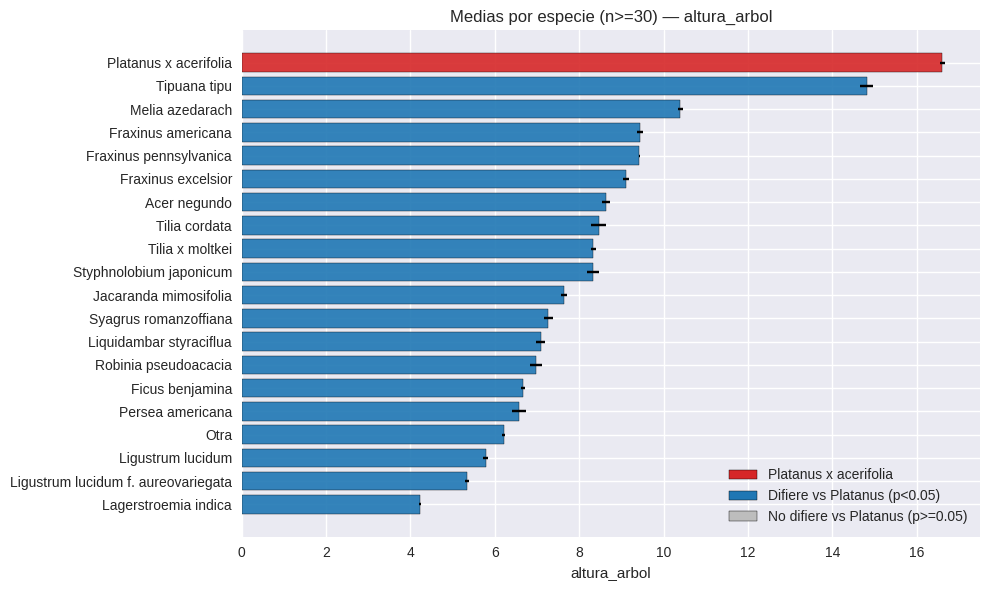


Resumen rápido: de 20 especies con n>=30, 19 difieren estadísticamente de Platanus x acerifolia (post-hoc Dunn, Holm).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


datos_limpios= pd.read_pickle('../data/datos_arbolado')
datos_limpios
datos_limpios['nombre_cientifico'].value_counts()
datos_limpios.to_csv('../data/datos.csv')
datos_limpios.head()
datos_limpios.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la lista de las 7 especies más comunes
top_species = datos_limpios['nombre_cientifico'].value_counts().nlargest(7).index

# 2. Filtramos el DataFrame para incluir solo esas especies
df_top_species = datos_limpios[
    datos_limpios['nombre_cientifico'].isin(top_species)
]

# 3. Creamos el Violin Plot
plt.figure(figsize=(13, 6))
sns.violinplot(
    data=df_top_species, 
    x='nombre_cientifico', 
    y='diametro_altura_pecho'
)
plt.title('Distribución del DAP por Especie (Top 7)', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la lista de las 7 especies más comunes
top_species = datos_limpios['nombre_cientifico'].value_counts().nlargest(7).index

# 2. Filtramos el DataFrame para incluir solo esas especies
df_top_species = datos_limpios[
    datos_limpios['nombre_cientifico'].isin(top_species)
]

# 3. Creamos el Violin Plot
plt.figure(figsize=(13, 6))
sns.violinplot(
    data=df_top_species, 
    x='nombre_cientifico', 
    y='altura_arbol'
)
plt.title('Distribución del altura por Especie (Top 7)', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
from scipy.stats import kruskal

# Supongamos que tus datos individuales están en 'datos_limpios' con la variable cluster asignada
variables = ['diametro_altura_pecho', 'altura_arbol']

for var in variables:
    grupos = [datos_limpios.loc[datos_limpios['nombre_cientifico'] == c, var] for c in sorted(datos_limpios['nombre_cientifico'].unique())]
    stat, p = kruskal(*grupos)
    print(f'{var}: estadístico H = {stat:.3f}, p = {p:.5f}')

import scikit_posthocs as sp
import pandas as pd

especie_objetivo = 'Platanus x acerifolia'   # Ajustar al nombre EXACTO en tu dataset
variables = ['diametro_altura_pecho', 'altura_arbol']

for var in variables:
    print(f'\nPOSTHOC VS {especie_objetivo.upper()} PARA {var.upper()}')

    # Posthoc Dunn con corrección de Holm
    dunn = sp.posthoc_dunn(
        datos_limpios,
        val_col=var,
        group_col='nombre_cientifico',
        p_adjust='holm'
    )

    # Extraer solo la fila correspondiente a Platanus
    pvals = dunn.loc[especie_objetivo, :]

    # Quitar self-comparison
    pvals = pvals.drop(index=especie_objetivo)

    # Crear DataFrame final
    comparaciones = pd.DataFrame({
        'p_valor': pvals,
        'significativa': pvals < 0.05
    })

    print(comparaciones)

# Requisitos: pandas, numpy, matplotlib, seaborn, scikit-posthocs, scipy
# pip install scikit-posthocs seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from scipy import stats

# Parámetros (ajustá según convenga)
especie_objetivo = 'Platanus x acerifolia'   # nombre EXACTO en tu dataset
variables = ['diametro_altura_pecho', 'altura_arbol']
min_count = 30   # mínimo de ejemplares por especie para incluir en la comparación/plot

# Función para calcular IC95 de la media (usando t para muestras pequeñas)
def mean_ci95(x):
    x = np.array(x.dropna())
    n = len(x)
    if n == 0:
        return (np.nan, np.nan, n)
    mean = x.mean()
    sem = stats.sem(x) if n > 1 else np.nan
    # t-critico con df = n-1, a 0.975
    if n > 1:
        tcrit = stats.t.ppf(0.975, df=n-1)
        ci = sem * tcrit
    else:
        ci = np.nan
    return mean, ci, n

for var in variables:
    print('\n' + '='*80)
    print(f'VARIABLE: {var}')
    print('='*80)
    # 1) Resumen por especie
    resumen = datos_limpios.groupby('nombre_cientifico')[var].apply(mean_ci95).rename('stats').reset_index()
    resumen[['media', 'ci95', 'n']] = pd.DataFrame(resumen['stats'].tolist(), index=resumen.index)
    resumen = resumen.drop(columns='stats')
    # Filtrar por n
    resumen = resumen.sort_values('media', ascending=False)
    resumen_filtered = resumen[resumen['n'] >= min_count].copy()
    if resumen_filtered.empty:
        print(f'No hay especies con al menos {min_count} observaciones para la variable {var}. Reduce min_count.')
        continue

    # 2) Post-hoc Dunn (Holm) sobre todas las especies
    dunn = sp.posthoc_dunn(datos_limpios, val_col=var, group_col='nombre_cientifico', p_adjust='holm')

    # Extraer p-vals vs Platanus
    if especie_objetivo not in dunn.index:
        raise ValueError(f"Especie objetivo '{especie_objetivo}' no encontrada en la columna 'nombre_cientifico'. Revisa el nombre exacto.")
    pvals_vs_platanus = dunn.loc[especie_objetivo, :].drop(index=especie_objetivo)
    pvals_vs_platanus = pvals_vs_platanus.rename('p_valor').reset_index().rename(columns={'index':'nombre_cientifico'})

    # 3) Mezclar con el resumen (solo especies con n >= min_count)
    resumen_plot = resumen_filtered.merge(pvals_vs_platanus, on='nombre_cientifico', how='left')
    resumen_plot['p_valor'] = resumen_plot['p_valor'].fillna(1.0)  # si no existe p-valor (por filtrado), marcar no significativo
    resumen_plot['significativa_vs_platanus'] = resumen_plot['p_valor'] < 0.05

    # 4) Mostrar tabla lista para informe
    display_cols = ['nombre_cientifico', 'n', 'media', 'ci95', 'p_valor', 'significativa_vs_platanus']
    tabla_para_informe = resumen_plot[display_cols].sort_values('media', ascending=False).reset_index(drop=True)
    # Formateo numérico legible
    tabla_para_informe['media'] = tabla_para_informe['media'].map(lambda x: f'{x:.2f}')
    tabla_para_informe['ci95'] = tabla_para_informe['ci95'].map(lambda x: f'±{x:.2f}' if pd.notnull(x) else '±NaN')
    tabla_para_informe['p_valor'] = tabla_para_informe['p_valor'].map(lambda x: f'{x:.2e}')
    tabla_para_informe['significativa_vs_platanus'] = tabla_para_informe['significativa_vs_platanus'].map({True:'Sí', False:'No'})

    print(tabla_para_informe.to_string(index=False))

    # 5) Gráfico: barras de medias con IC95, especies ordenadas por media, Platanus y significativos resaltados
    plt.figure(figsize=(10, max(6, 0.2*len(tabla_para_informe))))
    order = tabla_para_informe['nombre_cientifico'].values

    # colores: Platanus en color distinto, los que difieren en otro, resto gris
    colors = []
    for name, sig in zip(tabla_para_informe['nombre_cientifico'], tabla_para_informe['significativa_vs_platanus']):
        if name == especie_objetivo:
            colors.append('#d62728')  # rojo para Platanus
        else:
            colors.append('#1f77b4' if sig == 'Sí' else '#bdbdbd')  # azul si significativo, gris si no

    means = tabla_para_informe['media'].astype(float)
    ci95 = tabla_para_informe['ci95'].str.replace('±','').astype(float)

    ax = plt.gca()
    bars = ax.barh(order, means, xerr=ci95, align='center', color=colors, edgecolor='k', alpha=0.9)
    ax.invert_yaxis()  # mayor arriba
    ax.set_xlabel(var)
    ax.set_title(f'Medias por especie (n>={min_count}) — {var}')
    # leyenda manual
    from matplotlib.patches import Patch
    legend_items = [
        Patch(facecolor='#d62728', edgecolor='k', label=especie_objetivo),
        Patch(facecolor='#1f77b4', edgecolor='k', label='Difiere vs Platanus (p<0.05)'),
        Patch(facecolor='#bdbdbd', edgecolor='k', label='No difiere vs Platanus (p>=0.05)')
    ]
    ax.legend(handles=legend_items, loc='lower right')
    plt.tight_layout()
    plt.show()

    # 6) Resumen rápido imprimible para el informe
    n_signif = tabla_para_informe['significativa_vs_platanus'].value_counts().get('Sí', 0)
    total = len(tabla_para_informe)
    print(f'\nResumen rápido: de {total} especies con n>={min_count}, {n_signif} difieren estadísticamente de {especie_objetivo} (post-hoc Dunn, Holm).')


# Hipotesis 6